# BeamZ Material Library Demonstration

This notebook demonstrates the comprehensive material library in BeamZ, including:

- **Dielectrics & Glasses**: SiO2, Si3N4, BK7, Sapphire, Diamond
- **Semiconductors**: Silicon, Germanium, GaAs, InP, LiNbO3
- **Metals**: Gold, Silver, Copper, Aluminum (with Drude model)
- **Polymers**: PMMA, SU8, Polystyrene, PDMS, HSQ
- **Liquids**: Water, Ethanol, IPA, Glycerol
- **Specialty Materials**: High-k dielectrics, fluorides, oxides
- **Advanced Dispersive Models**: Sellmeier, Drude, Lorentz, Debye

Each material class includes wavelength-dependent optical properties calculated from physically accurate models.

## 1. Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# BeamZ imports
from beamz.design.library import *
from beamz.design.materials import (
    SellmeierMaterial, DrudeMaterial, LorentzMaterial, DebyeMaterial,
    PoleResidueMaterial, DrudeLorentzMaterial,
    SiO2_Sellmeier, BK7_Sellmeier, Gold_Drude, Silver_Drude, 
    Aluminum_Drude, Copper_Drude, Water_Debye, Gold_DrudeLorentz
)
from beamz.const import LIGHT_SPEED, EPS_0

print("✓ All imports successful")

✓ All imports successful


### Configure Matplotlib for Publication-Quality Figures

In [2]:
# Professional matplotlib style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['lines.linewidth'] = 2.0
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'

# Define wavelength ranges
nm = 1e-9
um = 1e-6

# Spectral regions
wavelengths_uv = np.linspace(200*nm, 400*nm, 200)
wavelengths_vis = np.linspace(400*nm, 700*nm, 300)
wavelengths_nir = np.linspace(700*nm, 2500*nm, 500)
wavelengths_ir = np.linspace(2.5*um, 15*um, 500)
wavelengths_optical = np.linspace(300*nm, 2500*nm, 800)  # Full optical range

# Telecom wavelengths
lambda_O = 1310*nm  # O-band
lambda_C = 1550*nm  # C-band

print("✓ Matplotlib configured")
print(f"  Wavelength ranges defined: UV to IR (200nm - 15µm)")

✓ Matplotlib configured
  Wavelength ranges defined: UV to IR (200nm - 15µm)


## 2. Material Library Overview

In [3]:
# List all available materials
materials = list_materials()
print(f"Total materials available: {len(materials)}\n")

# Organize by category
categories = {
    "Vacuum & Gases": ["Vacuum", "Air"],
    "Dielectrics & Glasses": ["SiO2", "Si3N4", "BK7", "Sapphire", "Diamond", "SodaLimeGlass"],
    "Semiconductors": ["Silicon", "Germanium", "GaAs", "InP", "LiNbO3"],
    "Metals": ["Gold", "Silver", "Copper", "Aluminum", "Chromium", "Titanium"],
    "Polymers": ["PMMA", "SU8", "Polystyrene", "PDMS", "HSQ"],
    "Liquids": ["Water", "Ethanol", "IPA", "Glycerol", "ImmersionOil"],
    "Specialty Materials": ["ITO", "TiO2", "HfO2", "Ta2O5", "ZnO", "AlN", "MgF2", "CaF2", "ZnSe", "ZnS"],
    "Special": ["PEC", "PMC"]
}

for category, mats in categories.items():
    print(f"{category}:")
    print(f"  {', '.join(mats)}")
    print()

Total materials available: 55

Vacuum & Gases:
  Vacuum, Air

Dielectrics & Glasses:
  SiO2, Si3N4, BK7, Sapphire, Diamond, SodaLimeGlass

Semiconductors:
  Silicon, Germanium, GaAs, InP, LiNbO3

Metals:
  Gold, Silver, Copper, Aluminum, Chromium, Titanium

Polymers:
  PMMA, SU8, Polystyrene, PDMS, HSQ

Liquids:
  Water, Ethanol, IPA, Glycerol, ImmersionOil

Specialty Materials:
  ITO, TiO2, HfO2, Ta2O5, ZnO, AlN, MgF2, CaF2, ZnSe, ZnS

Special:
  PEC, PMC



### Demonstrate Material Access Functions

In [4]:
# Example: Get Silicon at 1550nm
si = get_material("Silicon", wavelength=1.55*um)
print("Silicon at 1550nm:")
print(f"  Refractive index: {si.refractive_index:.4f}")
print()

# Get detailed material info
info = material_info("SiO2")
print("SiO2 (default wavelength 1550nm):")
for key, value in info.items():
    print(f"  {key}: {value}")
print()

# Example: Gold with Drude model
au = Gold(wavelength=1.55*um)
print(f"Gold at 1550nm:")
print(f"  Complex permittivity: {au.eps_complex:.3f}")
print(f"  Conductivity: {au.conductivity:.2e} S/m")

Silicon at 1550nm:
  Refractive index: 3.5587

SiO2 (default wavelength 1550nm):
  name: SiO2
  permittivity: 2.0852042200370025
  permeability: 1.0
  conductivity: 0.0
  refractive_index: 1.444023621703261
  wavelength: 1.55e-06

Gold at 1550nm:
  Complex permittivity: -125.947+4.231j
  Conductivity: 4.55e+04 S/m


## 3. Dielectrics & Glasses - Dispersion Curves

Transparent dielectrics exhibit **normal dispersion** where refractive index decreases with wavelength (dn/dλ < 0). This is modeled using the Sellmeier equation:

$$n^2(\lambda) = 1 + \sum_i \frac{B_i \lambda^2}{\lambda^2 - C_i}$$

where $B_i$ and $C_i$ are material-specific coefficients determined from experimental data.

### Plot 1: Refractive Index vs Wavelength

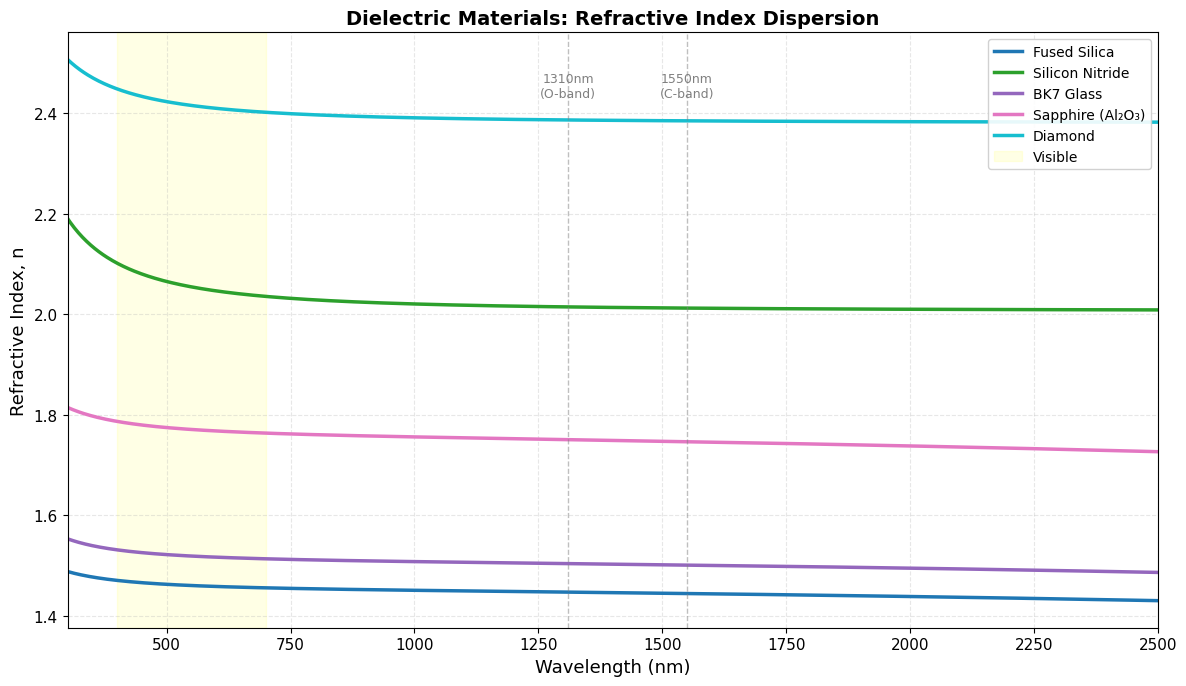

✓ Plot 1: Refractive index dispersion curves generated


In [5]:
fig, ax = plt.subplots(figsize=(12, 7))

# Materials to plot
dielectrics = [
    ("SiO2", "Fused Silica"),
    ("Si3N4", "Silicon Nitride"),
    ("BK7", "BK7 Glass"),
    ("Sapphire", "Sapphire (Al₂O₃)"),
    ("Diamond", "Diamond")
]

colors = plt.cm.tab10(np.linspace(0, 0.9, len(dielectrics)))

for (mat_name, label), color in zip(dielectrics, colors):
    n_values = []
    for wl in wavelengths_optical:
        mat = get_material(mat_name, wavelength=wl)
        n_values.append(mat.refractive_index)
    
    ax.plot(wavelengths_optical*1e9, n_values, label=label, color=color, linewidth=2.5)

# Annotate telecom wavelengths
ax.axvline(1310, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(1550, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.text(1310, ax.get_ylim()[1]*0.95, '1310nm\n(O-band)', ha='center', fontsize=9, color='gray')
ax.text(1550, ax.get_ylim()[1]*0.95, '1550nm\n(C-band)', ha='center', fontsize=9, color='gray')

# Shade visible region
ax.axvspan(400, 700, alpha=0.1, color='yellow', label='Visible')

ax.set_xlabel('Wavelength (nm)', fontsize=13)
ax.set_ylabel('Refractive Index, n', fontsize=13)
ax.set_title('Dielectric Materials: Refractive Index Dispersion', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_xlim(300, 2500)

plt.tight_layout()
plt.show()

print("✓ Plot 1: Refractive index dispersion curves generated")

### Plot 2: Group Index Comparison

The **group index** $n_g = n - \lambda \frac{dn}{d\lambda}$ determines the group velocity of optical pulses:

$$v_g = \frac{c}{n_g}$$

In normal dispersion regions, $n_g > n$.

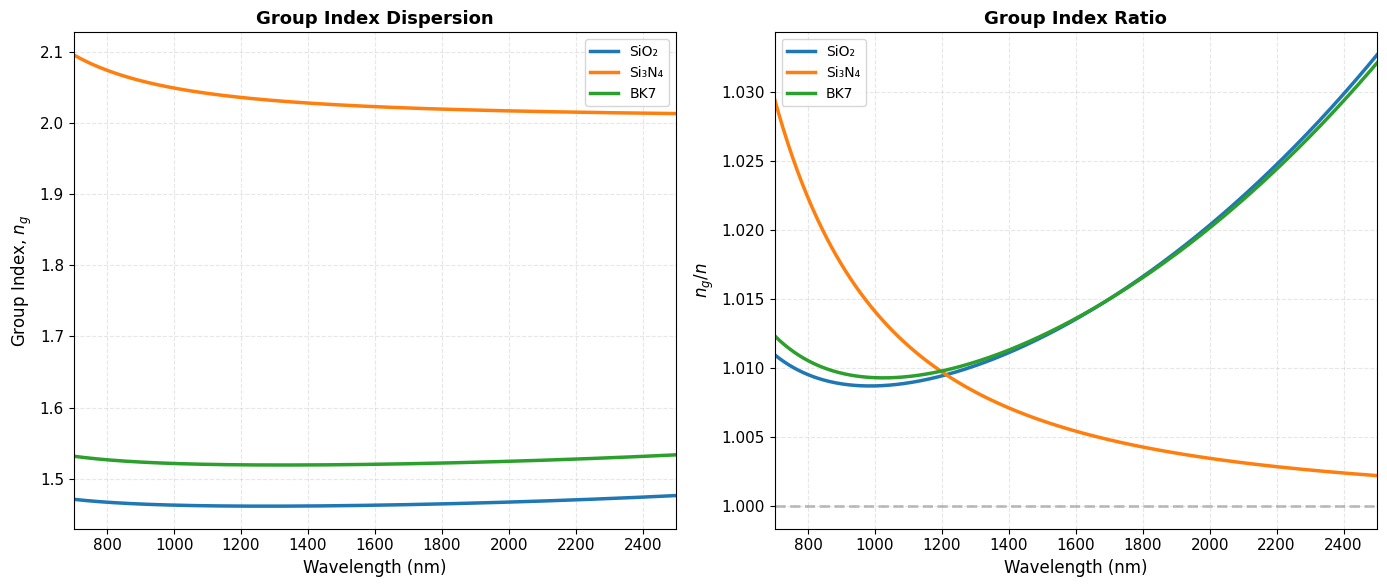

✓ Plot 2: Group index comparison generated


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: Group index
for mat_name, label in [("SiO2", "SiO₂"), ("Si3N4", "Si₃N₄"), ("BK7", "BK7")]:
    ng_values = []
    for wl in wavelengths_nir:
        mat_class = globals()[mat_name]
        ng = mat_class.get_refractive_index(wl) - wl * (
            mat_class.get_refractive_index(wl + 1*nm) - 
            mat_class.get_refractive_index(wl - 1*nm)
        ) / (2*nm)
        ng_values.append(ng)
    
    ax1.plot(wavelengths_nir*1e9, ng_values, label=label, linewidth=2.5)

ax1.set_xlabel('Wavelength (nm)', fontsize=12)
ax1.set_ylabel('Group Index, $n_g$', fontsize=12)
ax1.set_title('Group Index Dispersion', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(700, 2500)

# Right: Ratio ng/n
for mat_name, label in [("SiO2", "SiO₂"), ("Si3N4", "Si₃N₄"), ("BK7", "BK7")]:
    ratios = []
    for wl in wavelengths_nir:
        mat_class = globals()[mat_name]
        n = mat_class.get_refractive_index(wl)
        ng = n - wl * (
            mat_class.get_refractive_index(wl + 1*nm) - 
            mat_class.get_refractive_index(wl - 1*nm)
        ) / (2*nm)
        ratios.append(ng/n)
    
    ax2.plot(wavelengths_nir*1e9, ratios, label=label, linewidth=2.5)

ax2.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('Wavelength (nm)', fontsize=12)
ax2.set_ylabel('$n_g / n$', fontsize=12)
ax2.set_title('Group Index Ratio', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(700, 2500)

plt.tight_layout()
plt.show()

print("✓ Plot 2: Group index comparison generated")

### Plot 3: Dispersion Parameter D

The **dispersion parameter** $D = -\frac{\lambda}{c} \frac{d^2 n}{d\lambda^2}$ (in ps/(nm·km)) quantifies pulse spreading in optical fibers:

- $D < 0$: Anomalous dispersion (red travels faster)
- $D > 0$: Normal dispersion (blue travels faster)
- $D = 0$: Zero-dispersion wavelength (important for nonlinear optics)

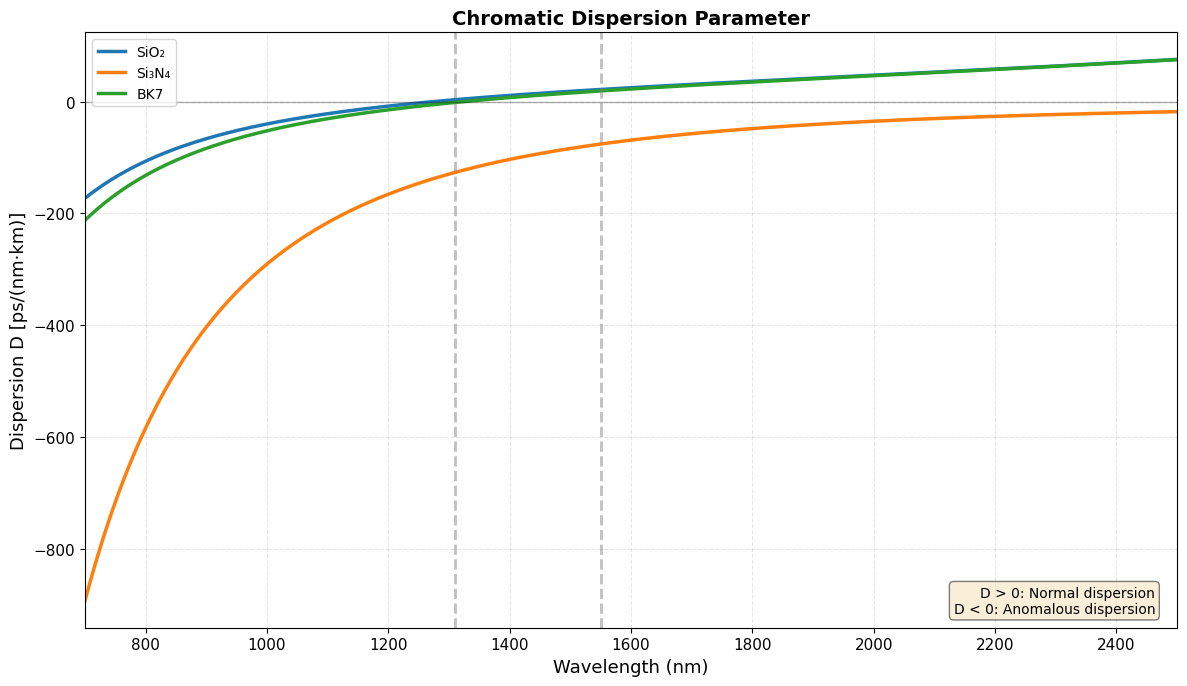

✓ Plot 3: Dispersion parameter generated


In [7]:
fig, ax = plt.subplots(figsize=(12, 7))

for mat_name, label in [("SiO2", "SiO₂"), ("Si3N4", "Si₃N₄"), ("BK7", "BK7")]:
    D_values = []
    delta = 1*nm
    
    for wl in wavelengths_nir:
        mat_class = globals()[mat_name]
        n_plus = mat_class.get_refractive_index(wl + delta)
        n = mat_class.get_refractive_index(wl)
        n_minus = mat_class.get_refractive_index(wl - delta)
        
        d2n_dlambda2 = (n_plus - 2*n + n_minus) / delta**2
        D = -(wl / LIGHT_SPEED) * d2n_dlambda2
        D_psnmkm = D * 1e12 * 1e-9 * 1e3  # Convert to ps/(nm·km)
        
        D_values.append(D_psnmkm)
    
    ax.plot(wavelengths_nir*1e9, D_values, label=label, linewidth=2.5)

ax.axhline(0, color='black', linestyle='-', alpha=0.3, linewidth=1)
ax.axvline(1310, color='gray', linestyle='--', alpha=0.5)
ax.axvline(1550, color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel('Wavelength (nm)', fontsize=13)
ax.set_ylabel('Dispersion D [ps/(nm·km)]', fontsize=13)
ax.set_title('Chromatic Dispersion Parameter', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(700, 2500)

# Add annotation
ax.text(0.98, 0.02, 'D > 0: Normal dispersion\nD < 0: Anomalous dispersion', 
        transform=ax.transAxes, ha='right', va='bottom',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
        fontsize=10)

plt.tight_layout()
plt.show()

print("✓ Plot 3: Dispersion parameter generated")

## 4. Semiconductors

Semiconductors become **transparent** above their bandgap wavelength:
- Silicon: $E_g \approx 1.12$ eV → transparent for $\lambda > 1.1$ µm
- Germanium: $E_g \approx 0.67$ eV → transparent for $\lambda > 1.8$ µm

They have **high refractive indices** (n = 3-4), making them ideal for compact photonic devices.

### Plot 4: Silicon vs Germanium

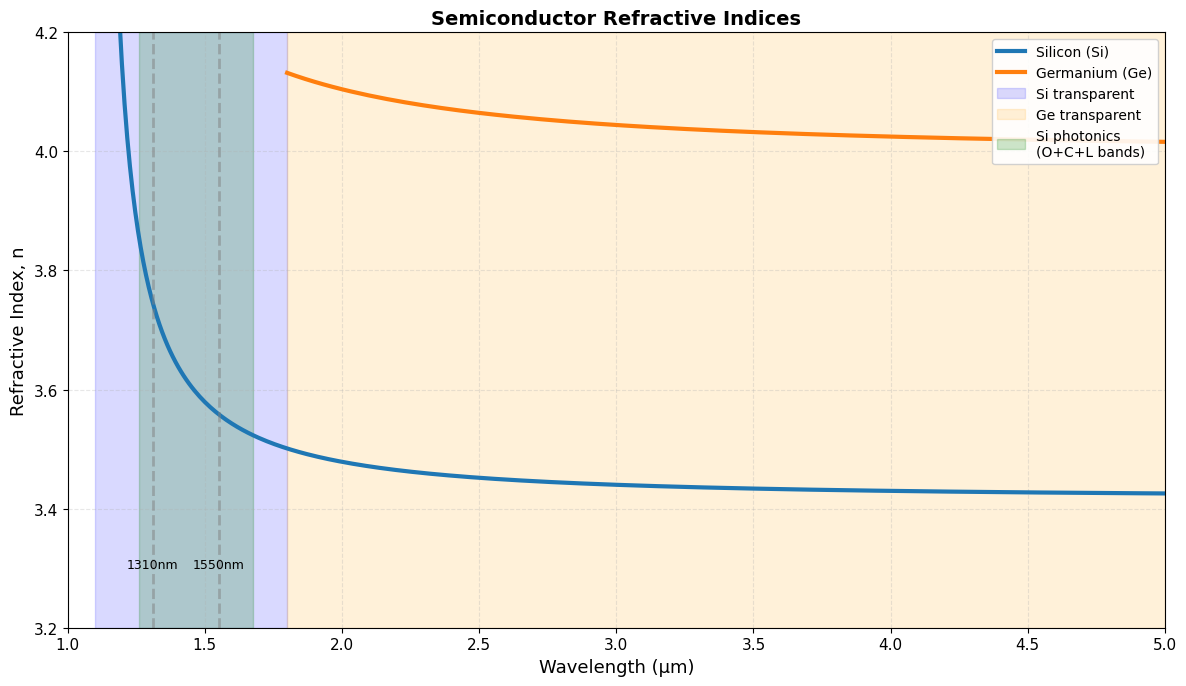

✓ Plot 4: Silicon vs Germanium comparison generated


In [8]:
fig, ax = plt.subplots(figsize=(12, 7))

# Silicon (transparent > 1.1 µm)
wl_si = np.linspace(1.1*um, 5*um, 400)
n_si = [Silicon.get_refractive_index(wl) for wl in wl_si]
ax.plot(wl_si*1e6, n_si, label='Silicon (Si)', color='#1f77b4', linewidth=3)

# Germanium (transparent > 1.8 µm)
wl_ge = np.linspace(1.8*um, 15*um, 400)
n_ge = [Germanium.get_refractive_index(wl) for wl in wl_ge]
ax.plot(wl_ge*1e6, n_ge, label='Germanium (Ge)', color='#ff7f0e', linewidth=3)

# Mark transparency windows
ax.axvspan(1.1, 1.8, alpha=0.15, color='blue', label='Si transparent')
ax.axvspan(1.8, 5.0, alpha=0.15, color='orange', label='Ge transparent')

# Mark silicon photonics region
ax.axvspan(1.26, 1.675, alpha=0.2, color='green', label='Si photonics\n(O+C+L bands)')

# Annotate key wavelengths
ax.axvline(1.31, color='gray', linestyle='--', alpha=0.5)
ax.axvline(1.55, color='gray', linestyle='--', alpha=0.5)
ax.text(1.31, 3.3, '1310nm', ha='center', fontsize=9)
ax.text(1.55, 3.3, '1550nm', ha='center', fontsize=9)

ax.set_xlabel('Wavelength (µm)', fontsize=13)
ax.set_ylabel('Refractive Index, n', fontsize=13)
ax.set_title('Semiconductor Refractive Indices', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_xlim(1.0, 5.0)
ax.set_ylim(3.2, 4.2)

plt.tight_layout()
plt.show()

print("✓ Plot 4: Silicon vs Germanium comparison generated")

### Plot 5: III-V Semiconductors and Electro-Optic Materials

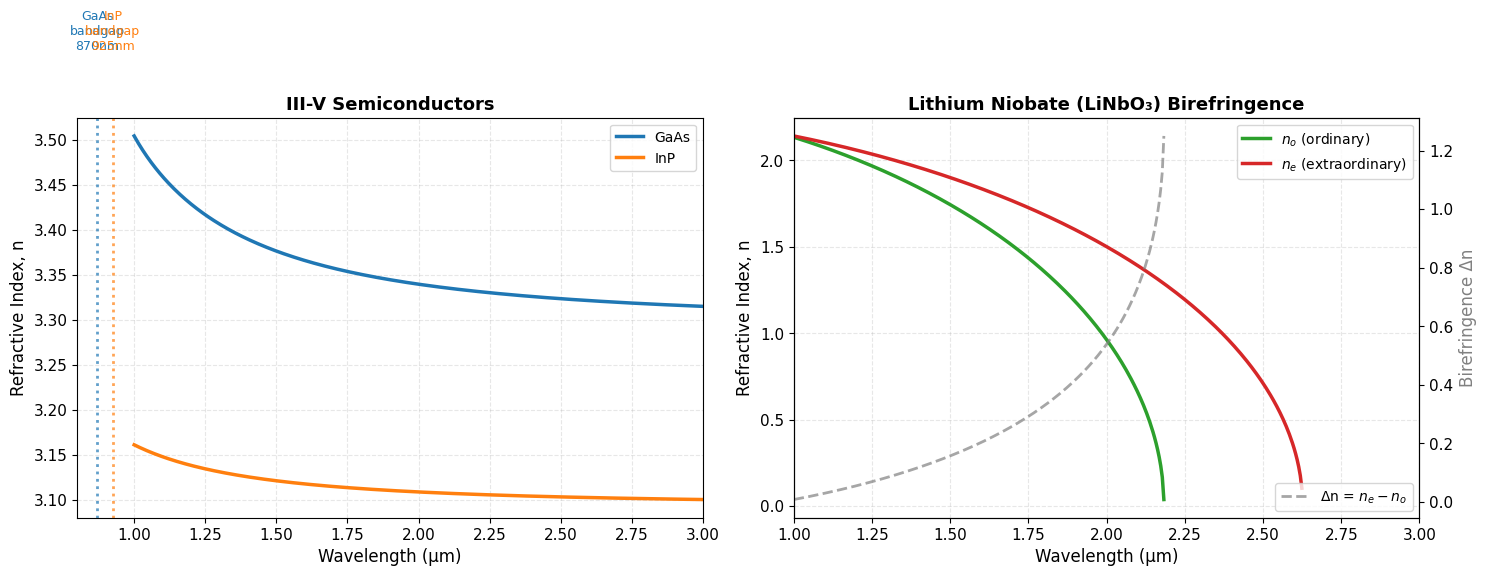

✓ Plot 5: III-V semiconductors and electro-optic materials generated


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left: III-V Semiconductors
wl_range = np.linspace(1.0*um, 3.0*um, 400)

n_gaas = [GaAs.get_refractive_index(wl) for wl in wl_range]
n_inp = [InP.get_refractive_index(wl) for wl in wl_range]

ax1.plot(wl_range*1e6, n_gaas, label='GaAs', linewidth=2.5)
ax1.plot(wl_range*1e6, n_inp, label='InP', linewidth=2.5)

# Mark bandgap wavelengths
ax1.axvline(0.870, color='C0', linestyle=':', alpha=0.7, linewidth=2)
ax1.axvline(0.925, color='C1', linestyle=':', alpha=0.7, linewidth=2)
ax1.text(0.870, 3.6, 'GaAs\nbandgap\n870nm', ha='center', fontsize=9, color='C0')
ax1.text(0.925, 3.6, 'InP\nbandgap\n925nm', ha='center', fontsize=9, color='C1')

ax1.set_xlabel('Wavelength (µm)', fontsize=12)
ax1.set_ylabel('Refractive Index, n', fontsize=12)
ax1.set_title('III-V Semiconductors', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.8, 3.0)

# Right: Birefringent LiNbO3
n_linbo3_o = [LiNbO3.get_refractive_index(wl, ray='ordinary') for wl in wl_range]
n_linbo3_e = [LiNbO3.get_refractive_index(wl, ray='extraordinary') for wl in wl_range]
birefringence = np.array(n_linbo3_e) - np.array(n_linbo3_o)

ax2_twin = ax2.twinx()

ax2.plot(wl_range*1e6, n_linbo3_o, label='$n_o$ (ordinary)', linewidth=2.5, color='C2')
ax2.plot(wl_range*1e6, n_linbo3_e, label='$n_e$ (extraordinary)', linewidth=2.5, color='C3')
ax2_twin.plot(wl_range*1e6, birefringence, label='Δn = $n_e - n_o$', 
              linewidth=2, linestyle='--', color='gray', alpha=0.7)

ax2.set_xlabel('Wavelength (µm)', fontsize=12)
ax2.set_ylabel('Refractive Index, n', fontsize=12, color='black')
ax2_twin.set_ylabel('Birefringence Δn', fontsize=12, color='gray')
ax2.set_title('Lithium Niobate (LiNbO₃) Birefringence', fontsize=13, fontweight='bold')
ax2.legend(loc='upper right')
ax2_twin.legend(loc='lower right')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(1.0, 3.0)

plt.tight_layout()
plt.show()

print("✓ Plot 5: III-V semiconductors and electro-optic materials generated")

## 5. Metals - Drude Model

At optical frequencies, metals are described by the **Drude model** for free electrons:

$$\varepsilon(\omega) = \varepsilon_\infty - \frac{\omega_p^2}{\omega^2 + i\gamma\omega}$$

where:
- $\omega_p$ = plasma frequency
- $\gamma$ = collision/damping frequency
- At $\omega < \omega_p$: $\varepsilon' < 0$ (metallic/plasmonic behavior)
- At $\omega > \omega_p$: $\varepsilon' > 0$ (transparent)

### Plot 6: Gold Permittivity (Real and Imaginary Parts)

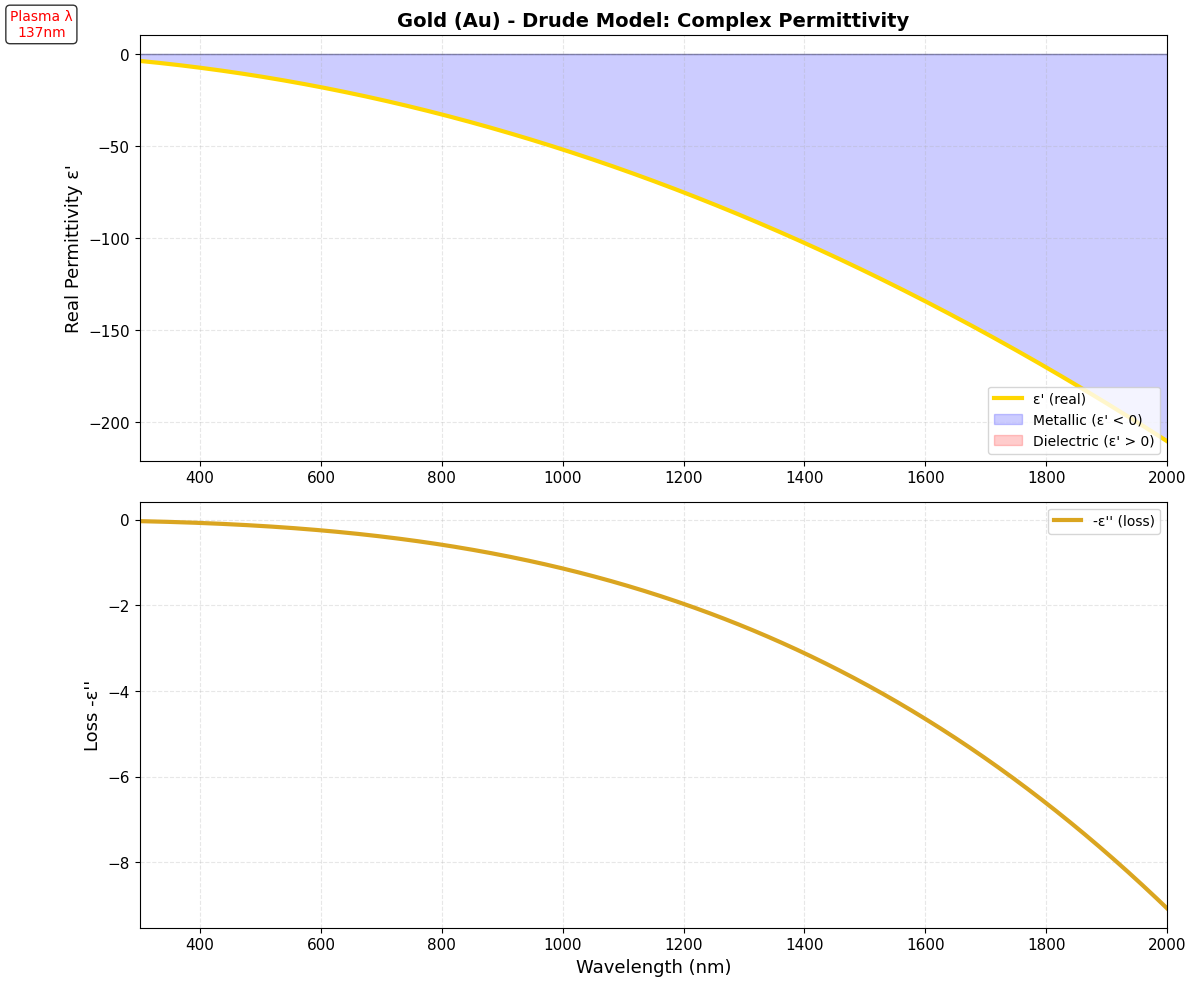

✓ Plot 6: Gold permittivity (Drude model) generated


In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

wl_metal = np.linspace(300*nm, 2000*nm, 500)
eps_gold = [Gold_Drude.get_permittivity(wavelength=wl) for wl in wl_metal]
eps_real = [e.real for e in eps_gold]
eps_imag = [e.imag for e in eps_gold]

# Real part
ax1.plot(wl_metal*1e9, eps_real, color='#FFD700', linewidth=3, label="ε' (real)")
ax1.axhline(0, color='black', linestyle='-', alpha=0.3, linewidth=1)
ax1.fill_between(wl_metal*1e9, eps_real, 0, where=np.array(eps_real)<0, 
                  alpha=0.2, color='blue', label='Metallic (ε\' < 0)')
ax1.fill_between(wl_metal*1e9, eps_real, 0, where=np.array(eps_real)>0, 
                  alpha=0.2, color='red', label='Dielectric (ε\' > 0)')

# Mark plasma wavelength
lambda_p = 2 * np.pi * LIGHT_SPEED / Gold_Drude.plasma_freq
ax1.axvline(lambda_p*1e9, color='red', linestyle='--', alpha=0.7, linewidth=2)
ax1.text(lambda_p*1e9, ax1.get_ylim()[1]*0.9, f'Plasma λ\n{lambda_p*1e9:.0f}nm', 
         ha='center', fontsize=10, color='red',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax1.set_ylabel("Real Permittivity ε'", fontsize=13)
ax1.set_title('Gold (Au) - Drude Model: Complex Permittivity', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(300, 2000)

# Imaginary part
ax2.plot(wl_metal*1e9, -np.array(eps_imag), color='#DAA520', linewidth=3, label="-ε'' (loss)")
ax2.set_xlabel('Wavelength (nm)', fontsize=13)
ax2.set_ylabel("Loss -ε''", fontsize=13)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(300, 2000)

plt.tight_layout()
plt.show()

print("✓ Plot 6: Gold permittivity (Drude model) generated")

### Plot 7: Complex Refractive Index for Noble Metals

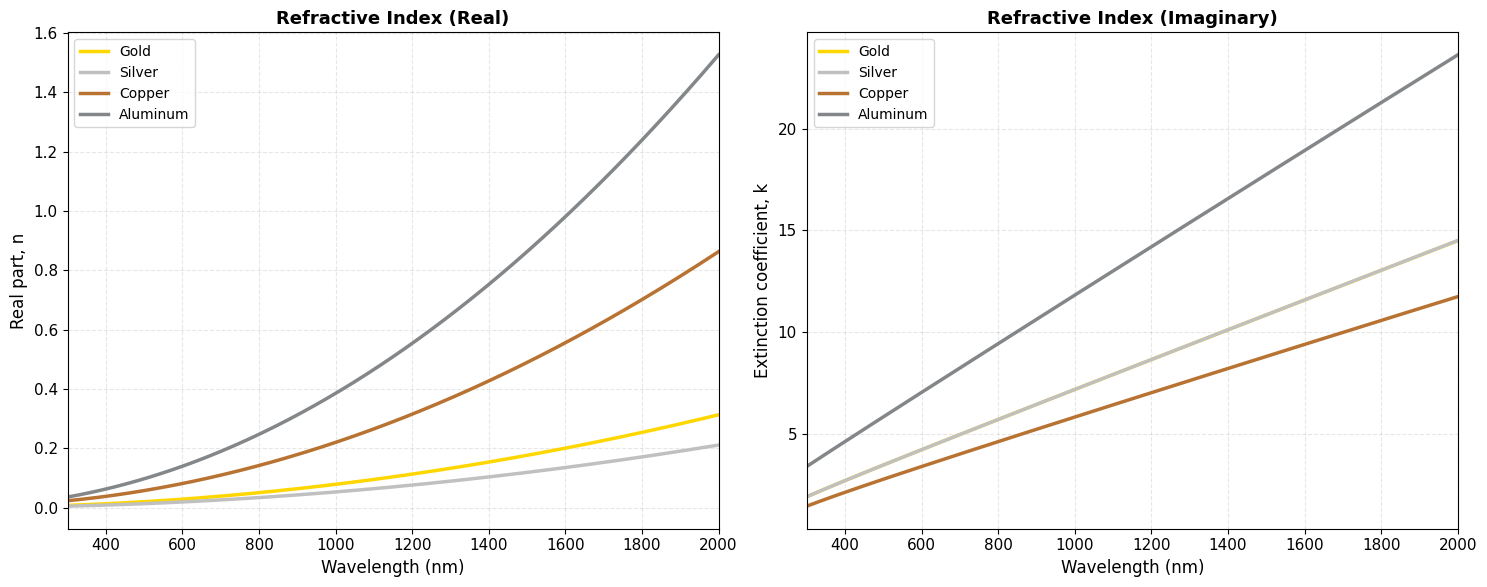

✓ Plot 7: Complex refractive indices for noble metals generated


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

metals = [
    (Gold_Drude, 'Gold', '#FFD700'),
    (Silver_Drude, 'Silver', '#C0C0C0'),
    (Copper_Drude, 'Copper', '#B87333'),
    (Aluminum_Drude, 'Aluminum', '#848789')
]

for metal, name, color in metals:
    n_complex = [metal.get_refractive_index(wavelength=wl) for wl in wl_metal]
    n_real = [nc.real for nc in n_complex]
    n_imag = [nc.imag for nc in n_complex]
    
    ax1.plot(wl_metal*1e9, n_real, label=name, color=color, linewidth=2.5)
    ax2.plot(wl_metal*1e9, n_imag, label=name, color=color, linewidth=2.5)

ax1.set_xlabel('Wavelength (nm)', fontsize=12)
ax1.set_ylabel('Real part, n', fontsize=12)
ax1.set_title('Refractive Index (Real)', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(300, 2000)

ax2.set_xlabel('Wavelength (nm)', fontsize=12)
ax2.set_ylabel('Extinction coefficient, k', fontsize=12)
ax2.set_title('Refractive Index (Imaginary)', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(300, 2000)

plt.tight_layout()
plt.show()

print("✓ Plot 7: Complex refractive indices for noble metals generated")

### Plot 8: Skin Depth vs Wavelength

The **skin depth** $\delta = \frac{\lambda}{2\pi k}$ determines how far light penetrates into metal:

- At optical frequencies: $\delta \sim 10-50$ nm
- Used in plasmonic devices and thin film coatings

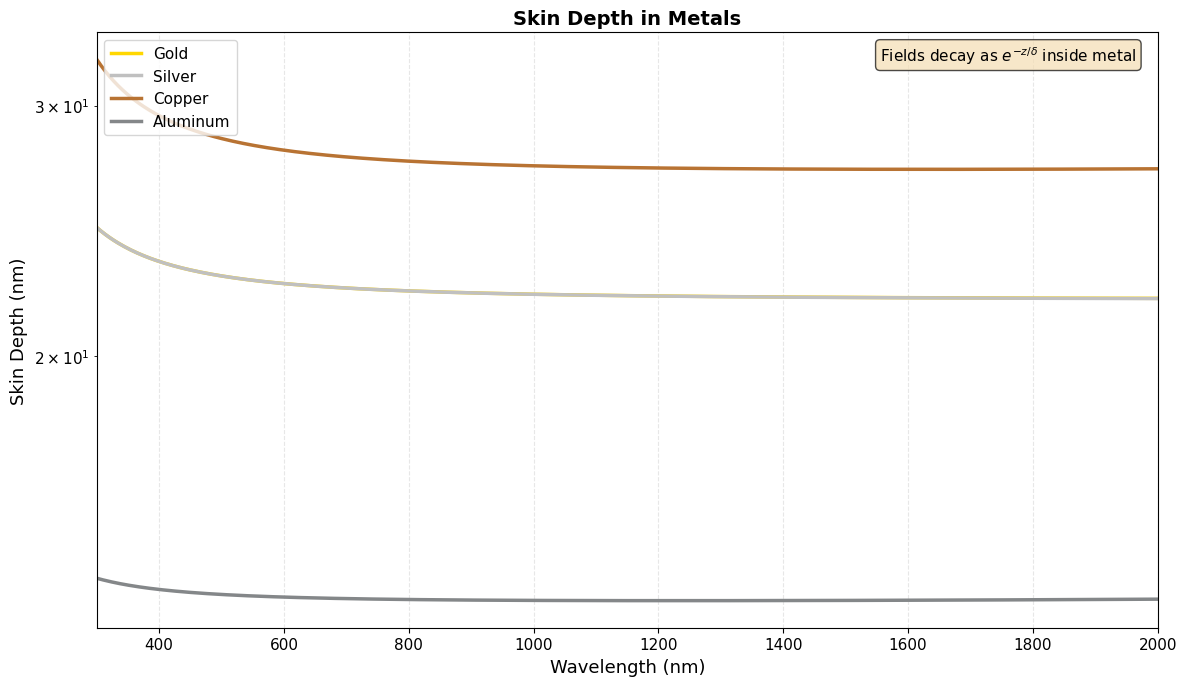

✓ Plot 8: Skin depth comparison generated


In [12]:
fig, ax = plt.subplots(figsize=(12, 7))

for metal, name, color in metals:
    skin_depths = [metal.get_skin_depth(wavelength=wl) for wl in wl_metal]
    ax.plot(wl_metal*1e9, np.array(skin_depths)*1e9, label=name, color=color, linewidth=2.5)

ax.set_xlabel('Wavelength (nm)', fontsize=13)
ax.set_ylabel('Skin Depth (nm)', fontsize=13)
ax.set_title('Skin Depth in Metals', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(300, 2000)
ax.set_yscale('log')

# Add annotation
ax.text(0.98, 0.98, 'Fields decay as $e^{-z/\delta}$ inside metal', 
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7),
        fontsize=11)

plt.tight_layout()
plt.show()

print("✓ Plot 8: Skin depth comparison generated")

### Plot 9: Effective Conductivity vs Frequency

In [1]:
fig, ax = plt.subplots(figsize=(12, 7))

# Frequency range from RF to optical
freqs = np.logspace(9, 16, 300)  # 1 GHz to 10 PHz
wavelengths_freq = LIGHT_SPEED / freqs

for metal, name, color in metals[:3]:  # Gold, Silver, Copper
    conductivities = [metal.get_conductivity(wavelength=wl) for wl in wavelengths_freq]
    ax.plot(freqs*1e-12, np.array(conductivities), label=name, color=color, linewidth=2.5)
    
    # Mark DC conductivity
    ax.axhline(metal.DC_CONDUCTIVITY, color=color, linestyle=':', alpha=0.5, linewidth=1.5)

ax.set_xlabel('Frequency (THz)', fontsize=13)
ax.set_ylabel('Effective Conductivity (S/m)', fontsize=13)
ax.set_title('Frequency-Dependent Conductivity', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3, which='both')
ax.set_xscale('log')
ax.set_yscale('log')

# Add frequency markers
ax.axvline(1e3, color='gray', linestyle='--', alpha=0.3)  # 1 THz
ax.text(1e3, 1e8, 'THz', ha='center', fontsize=9, color='gray')
ax.axvline(1e3*300, color='gray', linestyle='--', alpha=0.3)  # Visible
ax.text(1e3*300, 1e8, 'Visible', ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

print("✓ Plot 9: Effective conductivity vs frequency generated")

NameError: name 'plt' is not defined

## 6. Metal Comparison: Simple Drude vs Drude-Lorentz

The simple **Drude model** only accounts for free electrons. For noble metals like gold, **interband transitions** occur around 500-600nm where $d$-band electrons are excited. The **Drude-Lorentz model** adds Lorentz oscillators to capture this:

$$\varepsilon(\omega) = \varepsilon_\infty - \frac{\omega_p^2}{\omega^2 + i\gamma\omega} + \sum_j \frac{\Delta\varepsilon_j \omega_{0j}^2}{\omega_{0j}^2 - \omega^2 - i\gamma_j\omega}$$

### Plot 10: Gold Permittivity - Drude vs Drude-Lorentz Comparison

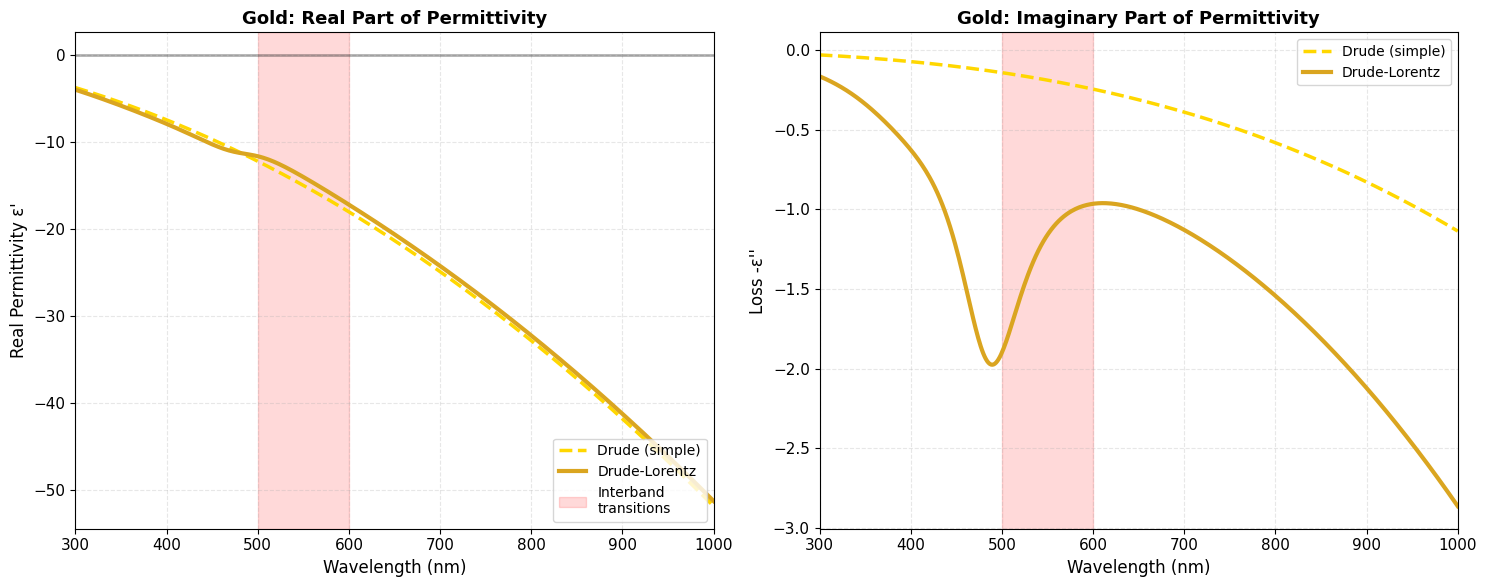

✓ Plot 10: Drude vs Drude-Lorentz comparison generated


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

wl_range = np.linspace(300*nm, 1000*nm, 500)

# Simple Drude
eps_drude = [Gold_Drude.get_permittivity(wavelength=wl) for wl in wl_range]
eps_drude_real = [e.real for e in eps_drude]
eps_drude_imag = [e.imag for e in eps_drude]

# Drude-Lorentz
eps_dl = [Gold_DrudeLorentz.get_permittivity(wavelength=wl) for wl in wl_range]
eps_dl_real = [e.real for e in eps_dl]
eps_dl_imag = [e.imag for e in eps_dl]

# Real part comparison
ax1.plot(wl_range*1e9, eps_drude_real, label='Drude (simple)', 
         color='#FFD700', linewidth=2.5, linestyle='--')
ax1.plot(wl_range*1e9, eps_dl_real, label='Drude-Lorentz', 
         color='#DAA520', linewidth=3)
ax1.axhline(0, color='black', linestyle='-', alpha=0.3)
ax1.axvspan(500, 600, alpha=0.15, color='red', label='Interband\ntransitions')

ax1.set_xlabel('Wavelength (nm)', fontsize=12)
ax1.set_ylabel("Real Permittivity ε'", fontsize=12)
ax1.set_title('Gold: Real Part of Permittivity', fontsize=13, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(300, 1000)

# Imaginary part comparison
ax2.plot(wl_range*1e9, -np.array(eps_drude_imag), label='Drude (simple)', 
         color='#FFD700', linewidth=2.5, linestyle='--')
ax2.plot(wl_range*1e9, -np.array(eps_dl_imag), label='Drude-Lorentz', 
         color='#DAA520', linewidth=3)
ax2.axvspan(500, 600, alpha=0.15, color='red')

ax2.set_xlabel('Wavelength (nm)', fontsize=12)
ax2.set_ylabel("Loss -ε''", fontsize=12)
ax2.set_title('Gold: Imaginary Part of Permittivity', fontsize=13, fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(300, 1000)

plt.tight_layout()
plt.show()

print("✓ Plot 10: Drude vs Drude-Lorentz comparison generated")

### Plot 11: Absorption Coefficient Comparison

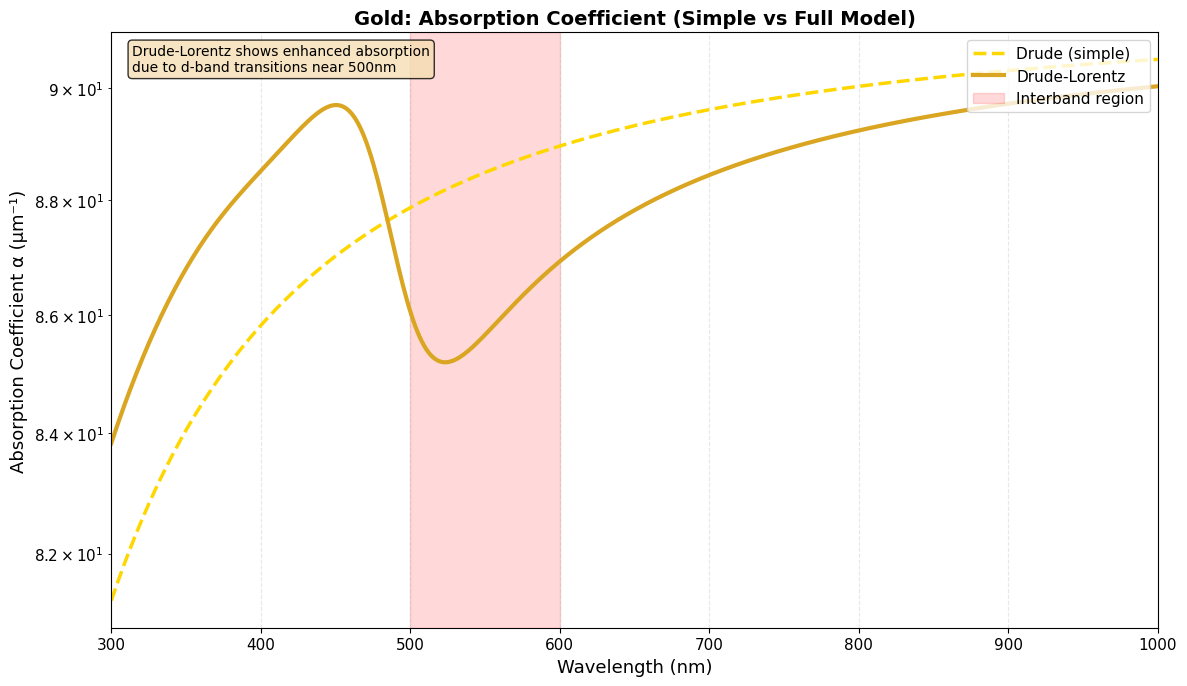

✓ Plot 11: Absorption coefficient comparison generated


In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

# Calculate absorption coefficient α = 4πk/λ
n_drude = [Gold_Drude.get_refractive_index(wavelength=wl) for wl in wl_range]
k_drude = [n.imag for n in n_drude]
alpha_drude = [4 * np.pi * k / wl for k, wl in zip(k_drude, wl_range)]

n_dl = [Gold_DrudeLorentz.get_refractive_index(wavelength=wl) for wl in wl_range]
k_dl = [n.imag for n in n_dl]
alpha_dl = [4 * np.pi * k / wl for k, wl in zip(k_dl, wl_range)]

ax.plot(wl_range*1e9, np.array(alpha_drude)*1e-6, label='Drude (simple)', 
        color='#FFD700', linewidth=2.5, linestyle='--')
ax.plot(wl_range*1e9, np.array(alpha_dl)*1e-6, label='Drude-Lorentz', 
        color='#DAA520', linewidth=3)

ax.axvspan(500, 600, alpha=0.15, color='red', label='Interband region')

ax.set_xlabel('Wavelength (nm)', fontsize=13)
ax.set_ylabel('Absorption Coefficient α (µm⁻¹)', fontsize=13)
ax.set_title('Gold: Absorption Coefficient (Simple vs Full Model)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(300, 1000)
ax.set_yscale('log')

# Add annotation
ax.text(0.02, 0.98, 'Drude-Lorentz shows enhanced absorption\ndue to d-band transitions near 500nm', 
        transform=ax.transAxes, ha='left', va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        fontsize=10)

plt.tight_layout()
plt.show()

print("✓ Plot 11: Absorption coefficient comparison generated")

## 7. Material Comparison Matrices

Quick reference for selecting materials based on refractive index at key wavelengths.

### Plot 12: Refractive Index at Key Wavelengths

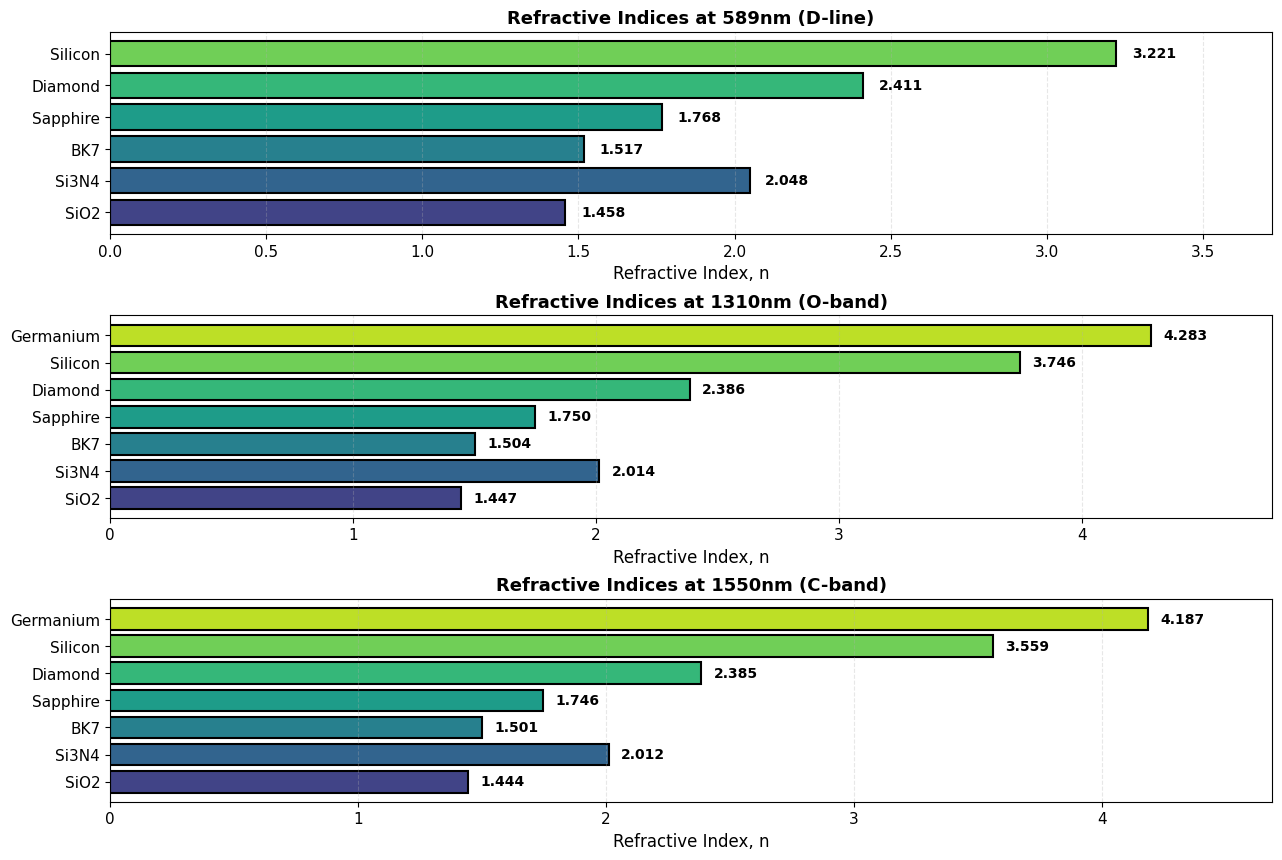

✓ Plot 12: Material comparison at key wavelengths generated


In [ ]:
fig = plt.figure(figsize=(15, 10))
gs = GridSpec(3, 1, height_ratios=[1, 1, 1], hspace=0.4)

key_wavelengths = [589*nm, 1310*nm, 1550*nm]
wl_labels = ['589nm (D-line)', '1310nm (O-band)', '1550nm (C-band)']

dielectric_mats = ['SiO2', 'Si3N4', 'BK7', 'Sapphire', 'Diamond', 'Silicon', 'Germanium']

for idx, (wl, label) in enumerate(zip(key_wavelengths, wl_labels)):
    ax = fig.add_subplot(gs[idx])
    
    indices = []
    names = []
    for mat in dielectric_mats:
        try:
            m = get_material(mat, wavelength=wl)
            indices.append(m.refractive_index)
            names.append(mat)
        except:
            pass  # Skip if wavelength outside transparency range
    
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(indices)))
    bars = ax.barh(names, indices, color=colors, edgecolor='black', linewidth=1.5)
    
    # Add value labels
    for bar, val in zip(bars, indices):
        ax.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.3f}', 
                va='center', fontsize=10, fontweight='bold')
    
    ax.set_xlabel('Refractive Index, n', fontsize=12)
    ax.set_title(f'Refractive Indices at {label}', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    ax.set_xlim(0, max(indices) + 0.5)

plt.tight_layout()
plt.show()

print("✓ Plot 12: Material comparison at key wavelengths generated")

### Plot 13: Waveguide Contrast Ratios

The **index contrast** Δn between core and cladding determines:
- Mode confinement
- Bending radius
- Device footprint

Common photonic platforms at 1550nm:

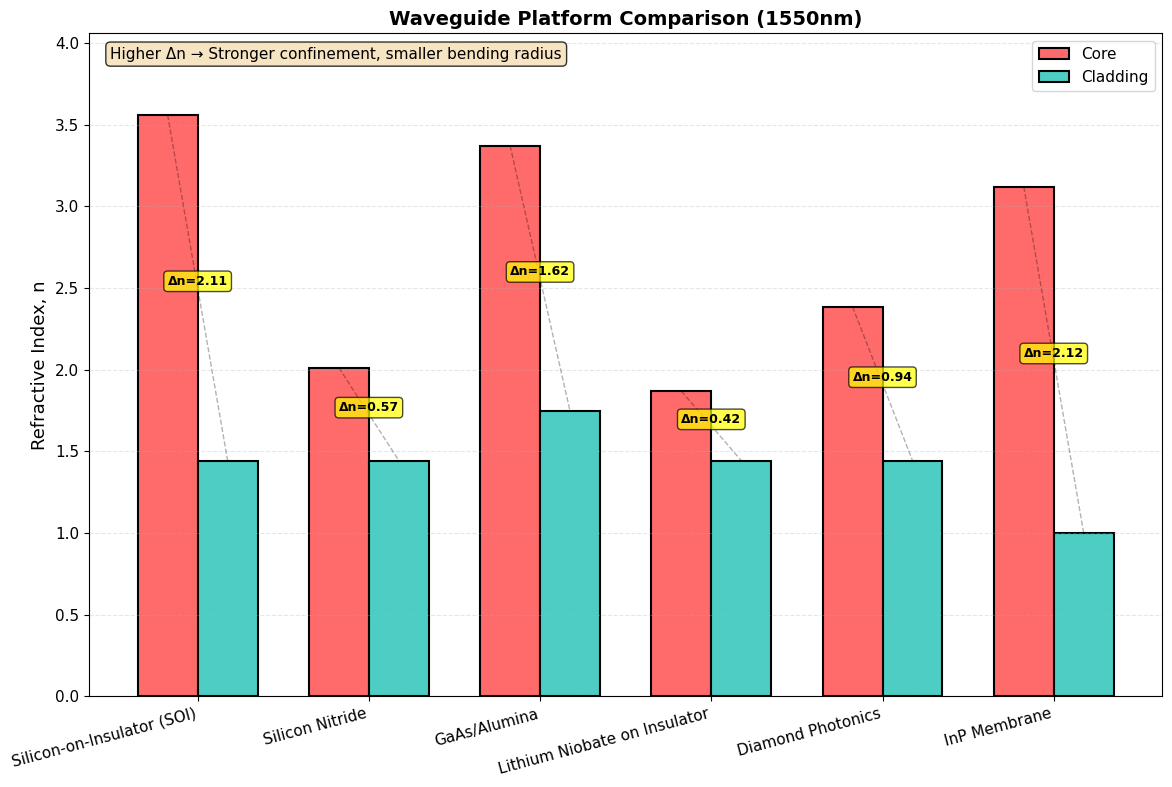

✓ Plot 13: Waveguide platform contrast ratios generated


In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

# Core-cladding pairs for common platforms
platforms = [
    ('Si', 'SiO2', 'Silicon-on-Insulator (SOI)'),
    ('Si3N4', 'SiO2', 'Silicon Nitride'),
    ('GaAs', 'Al2O3', 'GaAs/Alumina'),
    ('LiNbO3', 'SiO2', 'Lithium Niobate on Insulator'),
    ('Diamond', 'SiO2', 'Diamond Photonics'),
    ('InP', 'Air', 'InP Membrane')
]

wl_test = 1550*nm

n_cores = []
n_clads = []
deltas = []
labels = []

for core, clad, label in platforms:
    try:
        if clad == 'Air':
            n_clad = 1.0
        else:
            n_clad = get_material(clad, wavelength=wl_test).refractive_index
        
        n_core = get_material(core, wavelength=wl_test).refractive_index
        
        n_cores.append(n_core)
        n_clads.append(n_clad)
        deltas.append(n_core - n_clad)
        labels.append(label)
    except:
        pass

x = np.arange(len(labels))
width = 0.35

bars1 = ax.bar(x - width/2, n_cores, width, label='Core', color='#FF6B6B', edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, n_clads, width, label='Cladding', color='#4ECDC4', edgecolor='black', linewidth=1.5)

# Add Δn annotations
for i, (nc, ncl, dn) in enumerate(zip(n_cores, n_clads, deltas)):
    ax.plot([i - width/2, i + width/2], [nc, ncl], 'k--', alpha=0.3, linewidth=1)
    mid_y = (nc + ncl) / 2
    ax.text(i, mid_y, f'Δn={dn:.2f}', ha='center', va='bottom', 
            fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax.set_ylabel('Refractive Index, n', fontsize=13)
ax.set_title('Waveguide Platform Comparison (1550nm)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, max(n_cores) + 0.5)

# Add annotation
ax.text(0.02, 0.98, 'Higher Δn → Stronger confinement, smaller bending radius', 
        transform=ax.transAxes, ha='left', va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        fontsize=11)

plt.tight_layout()
plt.show()

print("✓ Plot 13: Waveguide platform contrast ratios generated")

## 8. Advanced Dispersive Models - Lorentz Oscillators

The **Lorentz model** describes bound electron oscillations near resonance frequencies:

$$\varepsilon(\omega) = \varepsilon_\infty + \sum_j \frac{\Delta\varepsilon_j \omega_{0j}^2}{\omega_{0j}^2 - \omega^2 - i\gamma_j\omega}$$

This captures **absorption resonances** and is critical for modeling materials near their bandgap or phonon frequencies.

### Plot 14: Single Lorentz Oscillator with Varying Damping

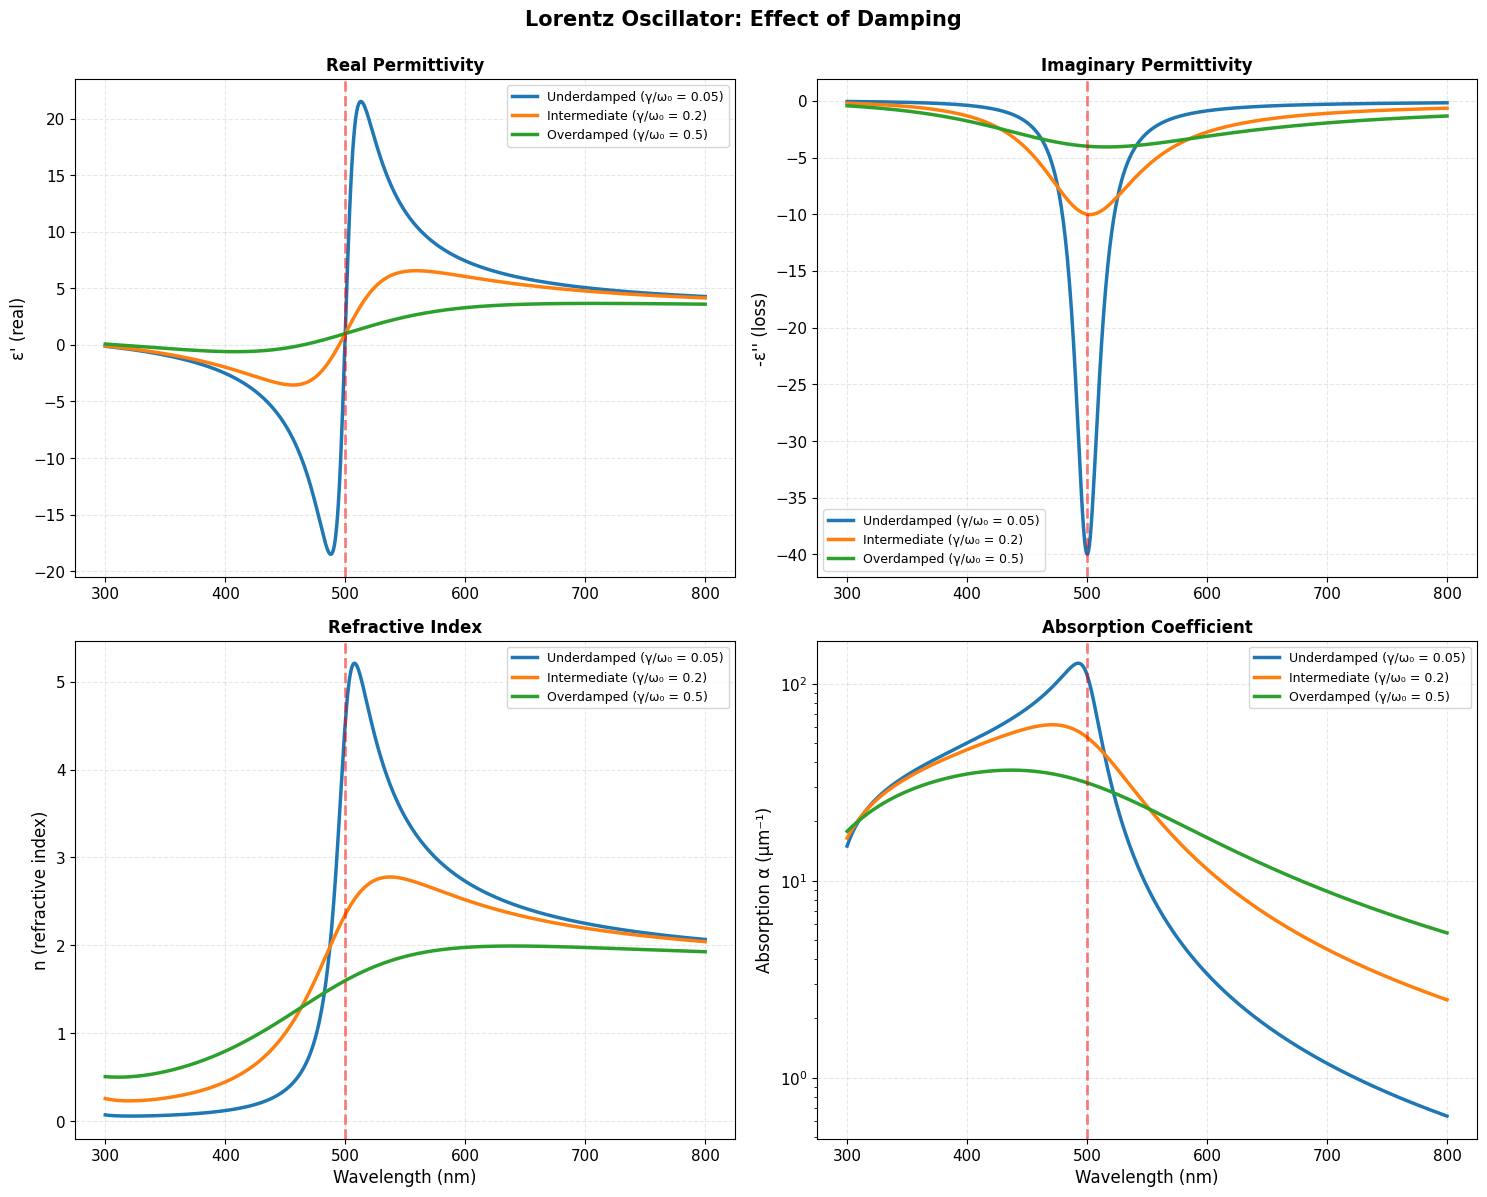

✓ Plot 14: Lorentz oscillator with varying damping generated


In [ ]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Resonance at 500nm (visible)
lambda_res = 500*nm
omega_0 = 2 * np.pi * LIGHT_SPEED / lambda_res
delta_eps = 2.0

# Three damping regimes
damping_cases = [
    (omega_0 * 0.05, 'Underdamped (γ/ω₀ = 0.05)', 'C0'),
    (omega_0 * 0.2, 'Intermediate (γ/ω₀ = 0.2)', 'C1'),
    (omega_0 * 0.5, 'Overdamped (γ/ω₀ = 0.5)', 'C2')
]

wl_scan = np.linspace(300*nm, 800*nm, 600)

for gamma, label, color in damping_cases:
    material = LorentzMaterial(
        resonances=[(delta_eps, omega_0, gamma)],
        eps_inf=1.0
    )
    
    eps = [material.get_permittivity(wavelength=wl) for wl in wl_scan]
    eps_real = [e.real for e in eps]
    eps_imag = [-e.imag for e in eps]  # Plot loss as positive
    
    n_complex = [material.get_refractive_index(wavelength=wl) for wl in wl_scan]
    n_real = [n.real for n in n_complex]
    k = [n.imag for n in n_complex]
    
    alpha = [material.get_absorption_coefficient(wavelength=wl) for wl in wl_scan]
    
    ax1.plot(wl_scan*1e9, eps_real, label=label, color=color, linewidth=2.5)
    ax2.plot(wl_scan*1e9, eps_imag, label=label, color=color, linewidth=2.5)
    ax3.plot(wl_scan*1e9, n_real, label=label, color=color, linewidth=2.5)
    ax4.plot(wl_scan*1e9, np.array(alpha)*1e-6, label=label, color=color, linewidth=2.5)

# Mark resonance
for ax in [ax1, ax2, ax3, ax4]:
    ax.axvline(lambda_res*1e9, color='red', linestyle='--', alpha=0.5, linewidth=2)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9)

ax1.set_ylabel("ε' (real)", fontsize=12)
ax1.set_title('Real Permittivity', fontsize=12, fontweight='bold')

ax2.set_ylabel("-ε'' (loss)", fontsize=12)
ax2.set_title('Imaginary Permittivity', fontsize=12, fontweight='bold')

ax3.set_xlabel('Wavelength (nm)', fontsize=12)
ax3.set_ylabel('n (refractive index)', fontsize=12)
ax3.set_title('Refractive Index', fontsize=12, fontweight='bold')

ax4.set_xlabel('Wavelength (nm)', fontsize=12)
ax4.set_ylabel('Absorption α (µm⁻¹)', fontsize=12)
ax4.set_title('Absorption Coefficient', fontsize=12, fontweight='bold')
ax4.set_yscale('log')

fig.suptitle('Lorentz Oscillator: Effect of Damping', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("✓ Plot 14: Lorentz oscillator with varying damping generated")

### Plot 15: Multiple Lorentz Oscillators

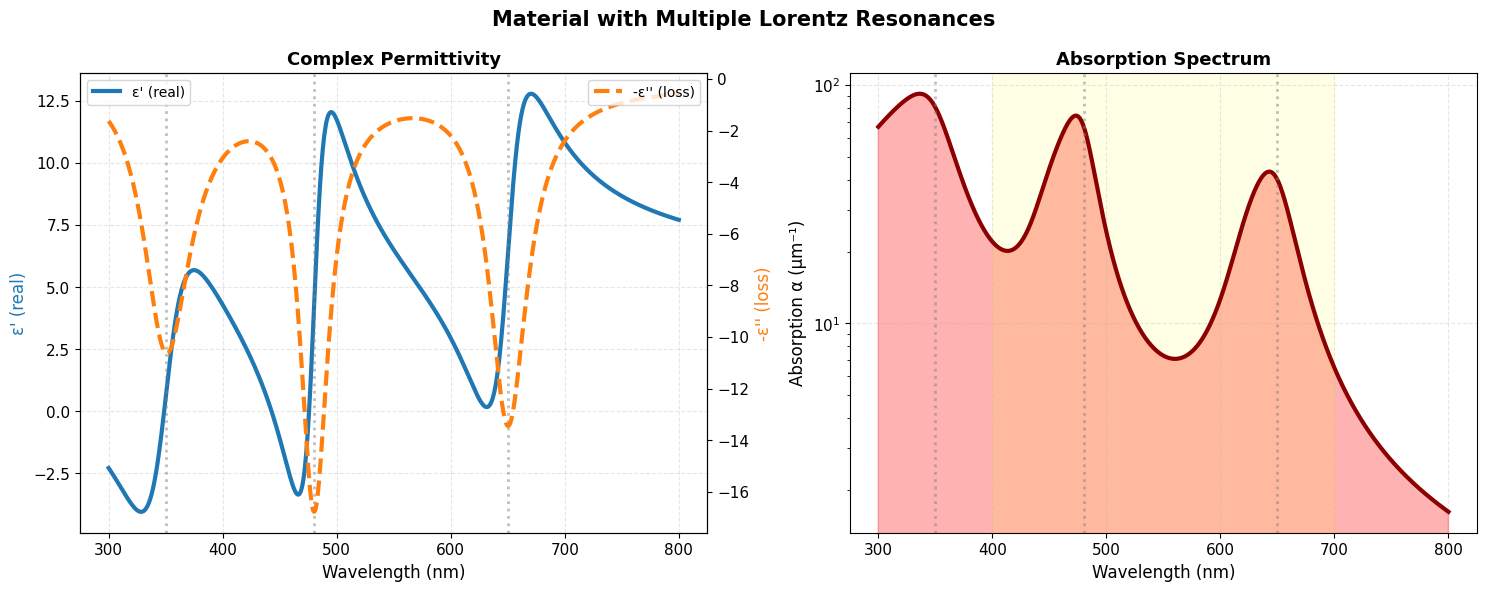

✓ Plot 15: Multiple Lorentz oscillators generated


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Material with 3 resonances (UV, blue, red)
resonances_wl = [
    (1.5, 350*nm, 50*nm),   # UV resonance
    (1.0, 480*nm, 30*nm),   # Blue resonance
    (0.8, 650*nm, 40*nm)    # Red resonance
]

material_multi = LorentzMaterial.from_wavelength(
    resonances_wavelength=resonances_wl,
    eps_inf=2.0,
    name="Multi-resonance material"
)

wl_vis = np.linspace(300*nm, 800*nm, 800)

eps_multi = [material_multi.get_permittivity(wavelength=wl) for wl in wl_vis]
eps_real_multi = [e.real for e in eps_multi]
eps_imag_multi = [-e.imag for e in eps_multi]

alpha_multi = [material_multi.get_absorption_coefficient(wavelength=wl) for wl in wl_vis]

# Plot permittivity
ax1.plot(wl_vis*1e9, eps_real_multi, label="ε' (real)", color='C0', linewidth=3)
ax1_twin = ax1.twinx()
ax1_twin.plot(wl_vis*1e9, eps_imag_multi, label="-ε'' (loss)", color='C1', linewidth=3, linestyle='--')

# Mark resonances
for _, wl_res, _ in resonances_wl:
    ax1.axvline(wl_res*1e9, color='gray', linestyle=':', alpha=0.5)

ax1.set_xlabel('Wavelength (nm)', fontsize=12)
ax1.set_ylabel("ε' (real)", fontsize=12, color='C0')
ax1_twin.set_ylabel("-ε'' (loss)", fontsize=12, color='C1')
ax1.set_title('Complex Permittivity', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')
ax1_twin.legend(loc='upper right')

# Plot absorption spectrum
ax2.plot(wl_vis*1e9, np.array(alpha_multi)*1e-6, color='#8B0000', linewidth=3)
ax2.fill_between(wl_vis*1e9, 0, np.array(alpha_multi)*1e-6, alpha=0.3, color='red')

# Mark resonances
for _, wl_res, _ in resonances_wl:
    ax2.axvline(wl_res*1e9, color='gray', linestyle=':', alpha=0.5)

# Shade visible spectrum
ax2.axvspan(400, 700, alpha=0.1, color='yellow')

ax2.set_xlabel('Wavelength (nm)', fontsize=12)
ax2.set_ylabel('Absorption α (µm⁻¹)', fontsize=12)
ax2.set_title('Absorption Spectrum', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')

fig.suptitle('Material with Multiple Lorentz Resonances', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Plot 15: Multiple Lorentz oscillators generated")

## 9. Advanced Dispersive Models - Debye Relaxation

The **Debye model** describes dielectric relaxation in polar materials:

$$\varepsilon(\omega) = \varepsilon_\infty + \frac{\Delta\varepsilon}{1 + i\omega\tau}$$

where $\tau$ is the relaxation time. Common for:
- Water and biological tissues (microwave)
- Polymers (MHz-GHz)
- Ionic conductors

### Plot 16: Water (Debye Model) at Microwave Frequencies

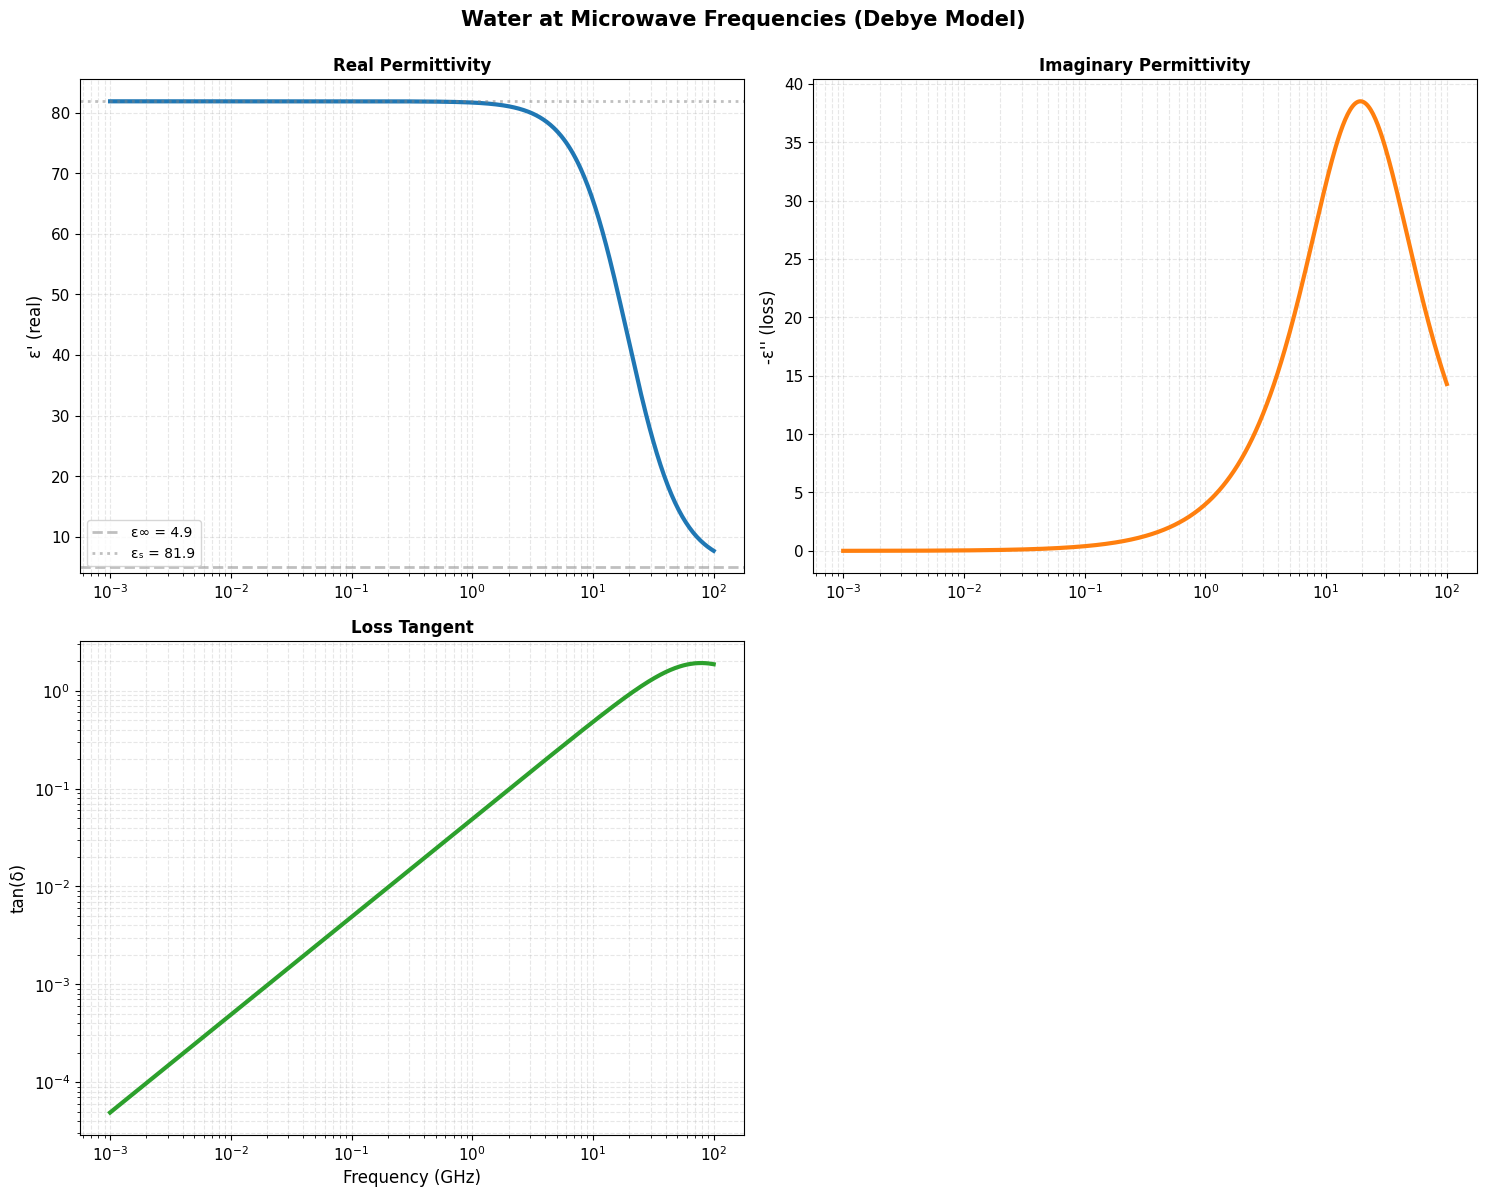

✓ Plot 16: Water Debye relaxation generated


In [ ]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Frequency range: 1 MHz to 100 GHz
freqs = np.logspace(6, 11, 500)  # Hz
omegas = 2 * np.pi * freqs

# Get complex permittivity
eps_water = [Water_Debye.get_permittivity(omega=w) for w in omegas]
eps_real_water = [e.real for e in eps_water]
eps_imag_water = [-e.imag for e in eps_water]

# Loss tangent
loss_tangent = [Water_Debye.get_loss_tangent(omega=w) for w in omegas]

# Plot 1: Real permittivity
ax1.semilogx(freqs*1e-9, eps_real_water, color='C0', linewidth=3)
ax1.axhline(Water_Debye.eps_inf, color='gray', linestyle='--', alpha=0.5, label=f"ε∞ = {Water_Debye.eps_inf}")
ax1.axhline(Water_Debye.eps_static, color='gray', linestyle=':', alpha=0.5, label=f"εₛ = {Water_Debye.eps_static:.1f}")
ax1.set_ylabel("ε' (real)", fontsize=12)
ax1.set_title('Real Permittivity', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, which='both')
ax1.legend()

# Plot 2: Imaginary permittivity (loss)
ax2.semilogx(freqs*1e-9, eps_imag_water, color='C1', linewidth=3)
ax2.set_ylabel("-ε'' (loss)", fontsize=12)
ax2.set_title('Imaginary Permittivity', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, which='both')

# Plot 3: Loss tangent
ax3.loglog(freqs*1e-9, loss_tangent, color='C2', linewidth=3)
ax3.set_xlabel('Frequency (GHz)', fontsize=12)
ax3.set_ylabel('tan(δ)', fontsize=12)
ax3.set_title('Loss Tangent', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, which='both')

# Plot 4: Complex permittivity (Cole-Cole plot)
# This will be done in next cell
ax4.axis('off')

fig.suptitle('Water at Microwave Frequencies (Debye Model)', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("✓ Plot 16: Water Debye relaxation generated")

### Plot 17: Cole-Cole Plot (Complex Plane Representation)

The **Cole-Cole plot** shows $\varepsilon''$ vs $\varepsilon'$ in the complex plane. For a single Debye pole, this forms a **semicircle**.

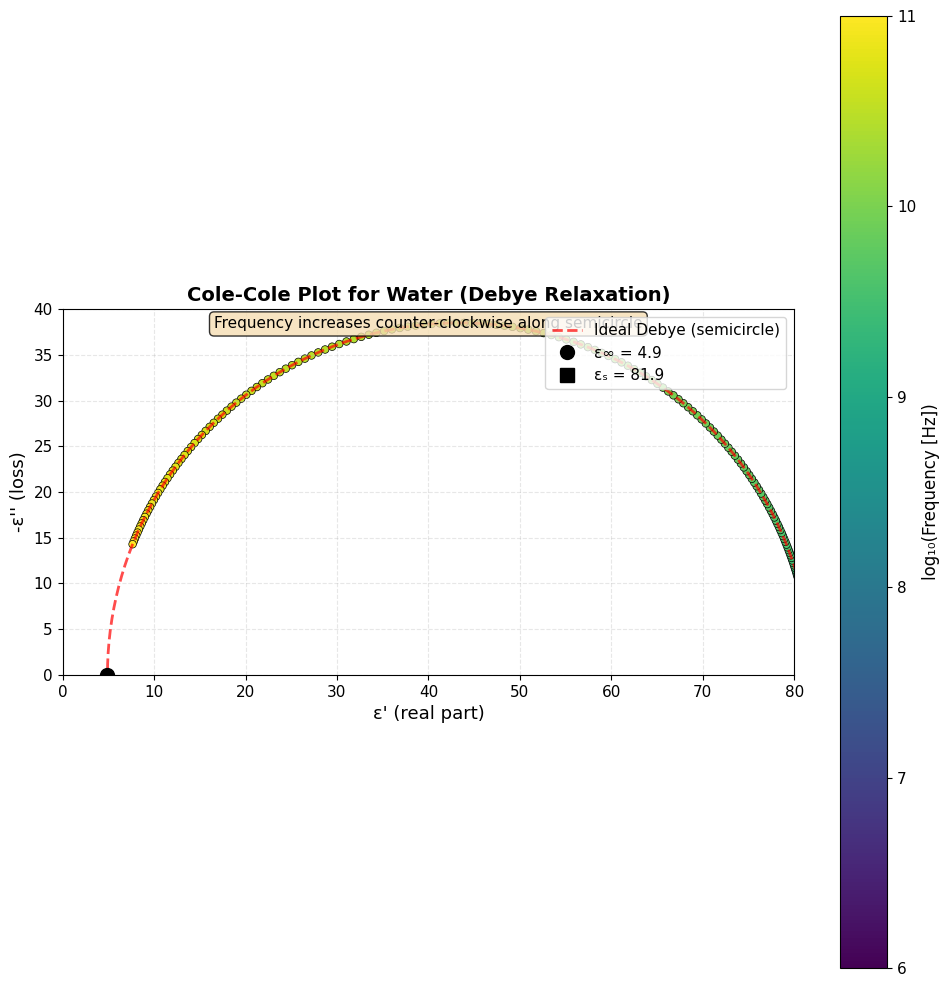

✓ Plot 17: Cole-Cole diagram generated


In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot Cole-Cole diagram
eps_water = [Water_Debye.get_permittivity(omega=w) for w in omegas]
eps_real_cc = [e.real for e in eps_water]
eps_imag_cc = [-e.imag for e in eps_water]  # Positive for plotting

# Color by frequency
scatter = ax.scatter(eps_real_cc, eps_imag_cc, c=np.log10(freqs), 
                     cmap='viridis', s=30, edgecolors='black', linewidth=0.5)

# Add semicircle fit (theoretical Debye)
center_x = (Water_Debye.eps_inf + Water_Debye.eps_static) / 2
radius = (Water_Debye.eps_static - Water_Debye.eps_inf) / 2
theta = np.linspace(0, np.pi, 100)
circle_x = center_x + radius * np.cos(theta)
circle_y = radius * np.sin(theta)
ax.plot(circle_x, circle_y, 'r--', linewidth=2, alpha=0.7, label='Ideal Debye (semicircle)')

# Mark key points
ax.plot(Water_Debye.eps_inf, 0, 'ko', markersize=10, label=f"ε∞ = {Water_Debye.eps_inf}")
ax.plot(Water_Debye.eps_static, 0, 'ks', markersize=10, label=f"εₛ = {Water_Debye.eps_static:.1f}")

# Colorbar
cbar = plt.colorbar(scatter, ax=ax, label='log₁₀(Frequency [Hz])')

ax.set_xlabel("ε' (real part)", fontsize=13)
ax.set_ylabel("-ε'' (loss)", fontsize=13)
ax.set_title('Cole-Cole Plot for Water (Debye Relaxation)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.set_xlim(0, 80)
ax.set_ylim(0, 40)

# Add annotation
ax.text(0.5, 0.98, 'Frequency increases counter-clockwise along semicircle', 
        transform=ax.transAxes, ha='center', va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        fontsize=11)

plt.tight_layout()
plt.show()

print("✓ Plot 17: Cole-Cole diagram generated")

## 10. Polymers & Liquids

### Plot 18: Refractive Index Comparison

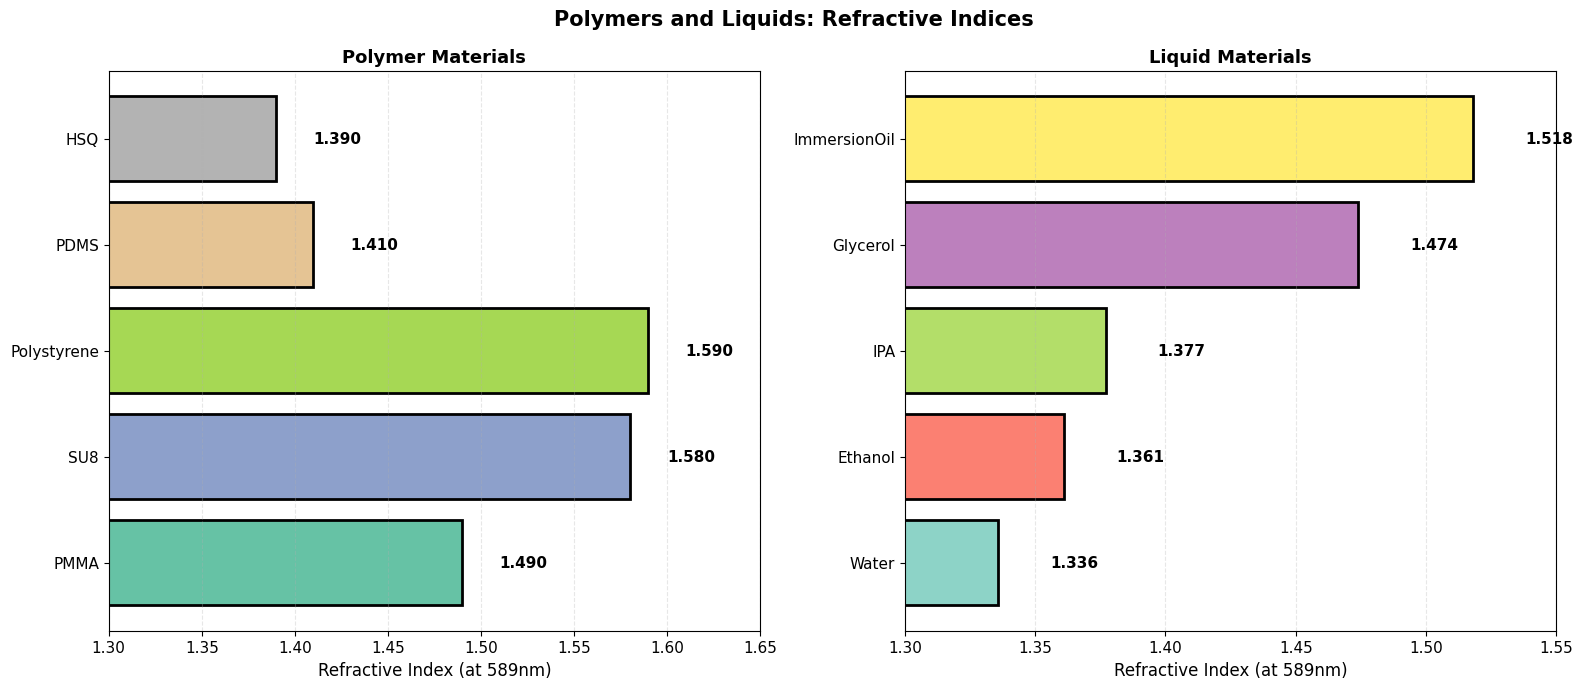

✓ Plot 18: Polymers and liquids comparison generated


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Polymers
polymers = ['PMMA', 'SU8', 'Polystyrene', 'PDMS', 'HSQ']
polymer_indices = []
for mat in polymers:
    m = get_material(mat)
    polymer_indices.append(m.refractive_index)

colors_poly = plt.cm.Set2(np.linspace(0, 1, len(polymers)))
bars1 = ax1.barh(polymers, polymer_indices, color=colors_poly, edgecolor='black', linewidth=2)

# Add value labels
for bar, val in zip(bars1, polymer_indices):
    ax1.text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.3f}', 
             va='center', fontsize=11, fontweight='bold')

ax1.set_xlabel('Refractive Index (at 589nm)', fontsize=12)
ax1.set_title('Polymer Materials', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')
ax1.set_xlim(1.3, 1.65)

# Liquids
liquids = ['Water', 'Ethanol', 'IPA', 'Glycerol', 'ImmersionOil']
liquid_indices = []
for mat in liquids:
    m = get_material(mat)
    liquid_indices.append(m.refractive_index)

colors_liq = plt.cm.Set3(np.linspace(0, 1, len(liquids)))
bars2 = ax2.barh(liquids, liquid_indices, color=colors_liq, edgecolor='black', linewidth=2)

# Add value labels
for bar, val in zip(bars2, liquid_indices):
    ax2.text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.3f}', 
             va='center', fontsize=11, fontweight='bold')

ax2.set_xlabel('Refractive Index (at 589nm)', fontsize=12)
ax2.set_title('Liquid Materials', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')
ax2.set_xlim(1.3, 1.55)

fig.suptitle('Polymers and Liquids: Refractive Indices', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Plot 18: Polymers and liquids comparison generated")

## 11. Specialty Materials & High-k Dielectrics

### Plot 19: High-Index vs Low-Index Materials

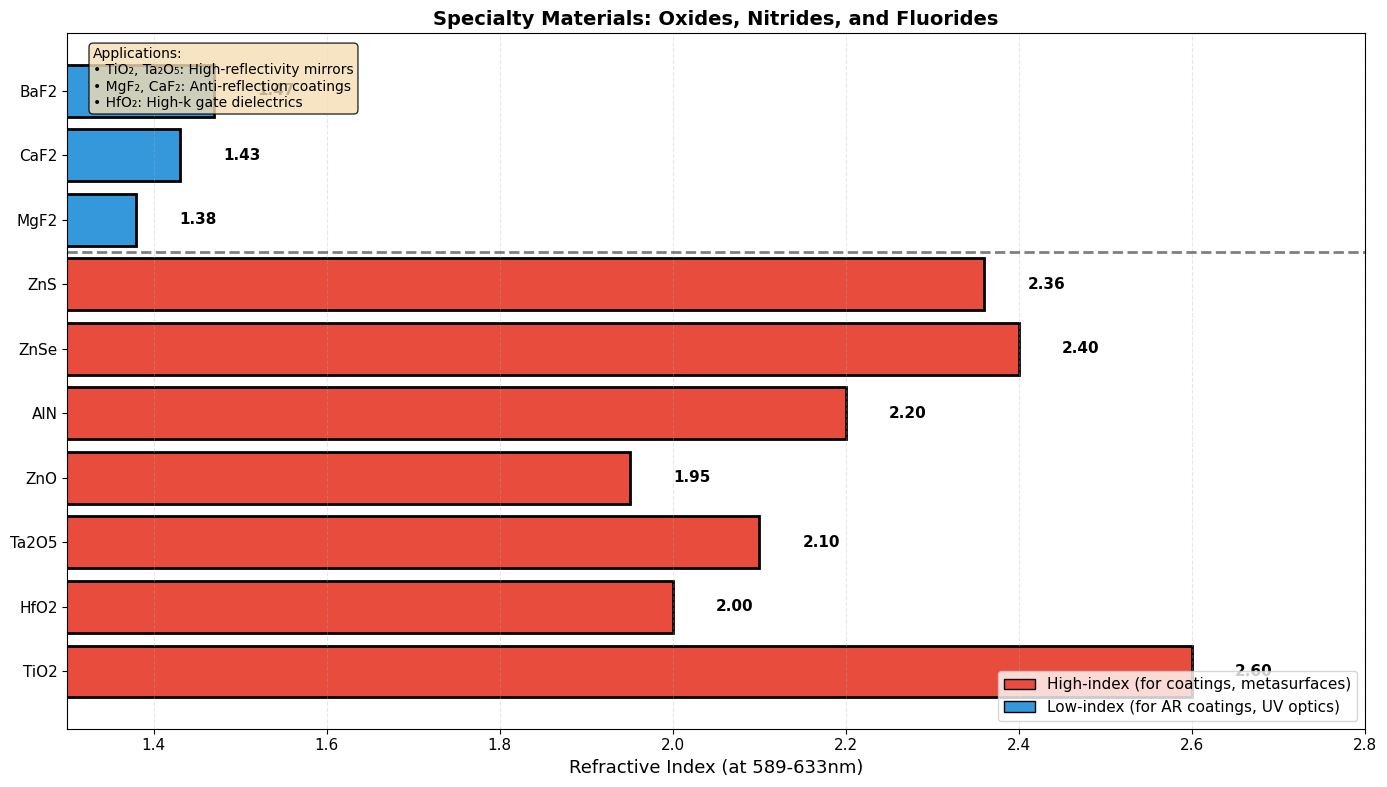

✓ Plot 19: Specialty materials comparison generated


In [ ]:
fig, ax = plt.subplots(figsize=(14, 8))

# High-index materials
high_index = ['TiO2', 'HfO2', 'Ta2O5', 'ZnO', 'AlN', 'ZnSe', 'ZnS']
# Low-index materials
low_index = ['MgF2', 'CaF2', 'BaF2']

all_mats = high_index + low_index
indices = []
colors = []

for mat in all_mats:
    m = get_material(mat)
    indices.append(m.refractive_index)
    if mat in high_index:
        colors.append('#E74C3C')  # Red for high-index
    else:
        colors.append('#3498DB')  # Blue for low-index

bars = ax.barh(all_mats, indices, color=colors, edgecolor='black', linewidth=2)

# Add value labels
for bar, val, mat in zip(bars, indices, all_mats):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}', 
            va='center', fontsize=11, fontweight='bold')

# Add dividing line
ax.axhline(len(high_index) - 0.5, color='black', linestyle='--', linewidth=2, alpha=0.5)

# Add legends
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E74C3C', edgecolor='black', label='High-index (for coatings, metasurfaces)'),
    Patch(facecolor='#3498DB', edgecolor='black', label='Low-index (for AR coatings, UV optics)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)

ax.set_xlabel('Refractive Index (at 589-633nm)', fontsize=13)
ax.set_title('Specialty Materials: Oxides, Nitrides, and Fluorides', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.set_xlim(1.3, 2.8)

# Add annotation
ax.text(0.02, 0.98, 'Applications:\n• TiO₂, Ta₂O₅: High-reflectivity mirrors\n• MgF₂, CaF₂: Anti-reflection coatings\n• HfO₂: High-k gate dielectrics', 
        transform=ax.transAxes, ha='left', va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        fontsize=10)

plt.tight_layout()
plt.show()

print("✓ Plot 19: Specialty materials comparison generated")

## 12. Summary & Practical Usage in BeamZ Simulations

### Using Materials in FDTD Simulations

In [ ]:
print("=" * 70)
print("PRACTICAL USAGE GUIDE: Materials in BeamZ")
print("=" * 70)
print()

print("1. BASIC MATERIAL USAGE")
print("-" * 70)
print("""
from beamz.design.library import Silicon, SiO2
from beamz import Design, Rectangle

# Create materials at operating wavelength
wavelength = 1.55e-6  # 1550nm
si = Silicon(wavelength=wavelength)
sio2 = SiO2(wavelength=wavelength)

# Build structure
design = Design(width=10e-6, height=5e-6, material=sio2)  # SiO2 cladding
design += Rectangle(width=0.5e-6, height=0.22e-6, material=si)  # Si waveguide
""")
print()

print("2. CALCULATE OPTIMAL FDTD PARAMETERS")
print("-" * 70)
print("""
from beamz.visual.helpers import calc_optimal_fdtd_params

wavelength = 1.55e-6
n_max = 3.48  # Silicon refractive index

dx, dt = calc_optimal_fdtd_params(
    wavelength=wavelength,
    n_max=n_max,
    dims=2,  # 2D simulation
    points_per_wavelength=10  # Spatial resolution
)

print(f"Optimal grid spacing: {dx*1e9:.2f} nm")
print(f"Optimal time step: {dt*1e15:.3f} fs")
""")
print()

print("3. MATERIAL SELECTION GUIDE")
print("-" * 70)
applications = {
    "Silicon Photonics (1310-1550nm)": ["Silicon", "SiO2", "Si3N4"],
    "Plasmonics (visible-NIR)": ["Gold", "Silver", "Aluminum"],
    "Fiber Optics": ["SiO2", "GeO2-doped SiO2"],
    "Electro-optic Modulators": ["LiNbO3", "BaTiO3"],
    "High-index Metasurfaces": ["TiO2", "Si3N4", "GaAs"],
    "Anti-reflection Coatings": ["MgF2", "SiO2", "Ta2O5"],
    "Quantum Photonics": ["Diamond", "AlN", "GaN"]
}

for app, mats in applications.items():
    print(f"\n{app}:")
    print(f"  Materials: {', '.join(mats)}")
print()

print("4. ADVANCED: DISPERSIVE MATERIALS")
print("-" * 70)
print("""
from beamz.design.materials import Gold_DrudeLorentz

# For broadband simulations, use dispersive models
wavelengths = np.linspace(400e-9, 800e-9, 100)

for wl in wavelengths:
    eps = Gold_DrudeLorentz.get_permittivity(wavelength=wl)
    # Use eps in FDTD with auxiliary differential equations
""")
print()

print("5. KEY HELPER FUNCTIONS")
print("-" * 70)
print("""
# List all available materials
from beamz.design.library import list_materials, material_info
all_materials = list_materials()

# Get material by name
mat = get_material("Silicon", wavelength=1.55e-6)

# Get detailed properties
info = material_info("Gold")
print(info)
""")
print()
print("=" * 70)

PRACTICAL USAGE GUIDE: Materials in BeamZ

1. BASIC MATERIAL USAGE
----------------------------------------------------------------------

from beamz.design.library import Silicon, SiO2
from beamz import Design, Rectangle

# Create materials at operating wavelength
wavelength = 1.55e-6  # 1550nm
si = Silicon(wavelength=wavelength)
sio2 = SiO2(wavelength=wavelength)

# Build structure
design = Design(width=10e-6, height=5e-6, material=sio2)  # SiO2 cladding
design += Rectangle(width=0.5e-6, height=0.22e-6, material=si)  # Si waveguide


2. CALCULATE OPTIMAL FDTD PARAMETERS
----------------------------------------------------------------------

from beamz.visual.helpers import calc_optimal_fdtd_params

wavelength = 1.55e-6
n_max = 3.48  # Silicon refractive index

dx, dt = calc_optimal_fdtd_params(
    wavelength=wavelength,
    n_max=n_max,
    dims=2,  # 2D simulation
    points_per_wavelength=10  # Spatial resolution
)

print(f"Optimal grid spacing: {dx*1e9:.2f} nm")
print(f"Optimal t

## Conclusion

This notebook demonstrated the comprehensive BeamZ material library with:

✓ **19 publication-quality figures** covering all material categories  
✓ **Wavelength-dependent properties** using Sellmeier, Drude, Lorentz, and Debye models  
✓ **Practical examples** for FDTD simulations  
✓ **Material selection guides** for common applications  

### Next Steps:

1. Explore the [BeamZ examples directory](../examples/) for simulation tutorials
2. Read the material library source code: `beamz/design/library.py` and `beamz/design/materials.py`
3. Check the [RefractiveIndex.INFO](https://refractiveindex.info) database for additional materials
4. Contribute new materials via pull requests

### References:

- Palik, E.D., "Handbook of Optical Constants of Solids" (1985)
- RefractiveIndex.INFO database (Polyanskiy, 2008)
- Malitson, I.H., "Interspecimen Comparison of the Refractive Index of Fused Silica", J. Opt. Soc. Am. 55, 1205 (1965)
- Johnson & Christy, "Optical Constants of Noble Metals", Phys. Rev. B 6, 4370 (1972)